# ResNet-UNet

This notebook uses the shared preprocessing notebook before defining the model.

In [1]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F


from torchvision.models import resnet34, ResNet34_Weights

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)


torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")
print(f"Using torch version: {torch.__version__}")

Using device: cpu
Using torch version: 2.13.0


In [3]:
# running preprocessing notebook

%run ../shared/preprocessing.ipynb

In [4]:
# Creating Data Loaders

train_loader, val_loader, test_loader, pos_weight = get_dataloaders( # type: ignore
    data_dir=DEFAULT_DATA_DIR, # type: ignore
    batch_size=32,
    augment_train=True,
    num_workers=0,
)

print("Input channels:", NUM_CHANNELS) # type: ignore
print("Positive-class weight:", pos_weight)
print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

I0000 00:00:1790388248.890432 4100013 tf_record_dataset_op.cc:390] TFRecordDataset `buffer_size` is unspecified, default to 262144


Input channels: 12
Positive-class weight: 20.0
Train batches: 469
Validation batches: 59
Test batches: 53


In [5]:
inputs, targets, valid_mask = next(iter(train_loader))

print("Inputs: ", inputs.shape, inputs.dtype)
print("Targets: ", targets.shape, targets.dtype)
print("Valid mask: ", valid_mask.shape, valid_mask.dtype)

print("Target values: ", torch.unique(targets))
print("Mask values: ", torch.unique(valid_mask))

assert inputs.shape[1:] == (12, 64, 64)
assert targets.shape[1:] == (1, 64, 64)
assert valid_mask.shape == targets.shape
assert torch.isfinite(inputs).all()

print("Data contract verified successfully.")

Inputs:  torch.Size([32, 12, 64, 64]) torch.float32
Targets:  torch.Size([32, 1, 64, 64]) torch.float32
Valid mask:  torch.Size([32, 1, 64, 64]) torch.float32
Target values:  tensor([-1.,  0.,  1.])
Mask values:  tensor([0., 1.])
Data contract verified successfully.


# Build ResNet34–UNet

## Decoder Block

In [6]:
class DecoderBlock(nn.Module):
    def __init__(self, input_channels, skip_channels, output_channels):
        super().__init__()
        
        self.conv = nn.Sequential(
            nn.Conv2d(
                input_channels + skip_channels,
                output_channels,
                kernel_size=3,
                padding=1,
            ),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                output_channels,
                output_channels,
                kernel_size=3,
                padding=1,
            ),
            nn.ReLU(inplace=True),
        )
    
    def forward(self, x, skip):
        # Make x the sme height and width as skip feature
        
        x = F.interpolate(
            x,
            size=skip.shape[2:],
            mode="bilinear",
            align_corners=False,
        )
        
        # join detailed encoder features with upsampled decoder features
        x = torch.cat([x, skip], dim=1)
        return self.conv(x)

## Full Model

In [7]:
class ResNet34UNet(nn.Module):
    def __init__(self, input_channels=12):
        super().__init__()
        
        #Load renNet34 with Imagenet-trained weights
        self.encoder = resnet34(
            weights= ResNet34_Weights.IMAGENET1K_V1
        )
        
        # It's original first convolution accepts 3 RGB channels
        old_conv = self.encoder.conv1
        
        # Replace it with a convolution that accepts our 12 features
        new_conv = nn.Conv2d(
            input_channels,
            64,
            kernel_size=7,
            stride=2,
            padding=3,
            bias=False,
        )
        
        # Initiate the new convolution from the pretrained RGB weights
        with torch.no_grad():
            rgb_average = old_conv.weight.mean(dim=1, keepdim=True)
            new_weights = rgb_average.repeat(
                1,
                input_channels,
                1,
                1
            ) * (3 / input_channels)
            
            new_conv.weight.copy_(new_weights)
            
            
        self.encoder.conv1 = new_conv
        
        # The classification layer is not needed for segmentation
        self.encoder.fc = nn.Identity() # type: ignore
        
        # Decorder: small features maps become layer step by step
        
        self.up4 = DecoderBlock(512, 256, 256)
        self.up3 = DecoderBlock(256, 128, 128)
        self.up2 = DecoderBlock(128, 64, 64)
        self.up1 = DecoderBlock(64, 64, 64)
        self.up0 = DecoderBlock(64, input_channels, 32)
        
        # One output value for each pixel: fire prediction logit.
        self.output_conv = nn.Conv2d(32, 1, kernel_size=1)
    
    
    def forward(self, x):
        original_inputs = x  # Save the 12-channel, 64 × 64 input

        skip0 = self.encoder.relu(
            self.encoder.bn1(self.encoder.conv1(x))
        )                                                  # 32 × 32

        skip1 = self.encoder.layer1(
            self.encoder.maxpool(skip0)
        )                                                  # 16 × 16
        skip2 = self.encoder.layer2(skip1)                 # 8 × 8
        skip3 = self.encoder.layer3(skip2)                 # 4 × 4
        bottom = self.encoder.layer4(skip3)                # 2 × 2

        x = self.up4(bottom, skip3)                        # 4 × 4
        x = self.up3(x, skip2)                             # 8 × 8
        x = self.up2(x, skip1)                             # 16 × 16
        x = self.up1(x, skip0)                             # 32 × 32
        x = self.up0(x, original_inputs)                   # 64 × 64

        return self.output_conv(x)
    

## Building Model

In [8]:
model = ResNet34UNet(input_channels=NUM_CHANNELS).to(device) # type: ignore
model.eval()

with torch.no_grad():
    predictions = model(inputs[:2].to(device))

print("Model output:", predictions.shape)
print("Target shape:", targets[:2].shape)

Model output: torch.Size([2, 1, 64, 64])
Target shape: torch.Size([2, 1, 64, 64])


# Verify the loss

## Define the loss

In [9]:
def masked_bce_dice_loss(logits, targets, valid_mask, pos_weight):
    # BCE accepts only targets from 0 to 1.
    # Give uncertain (-1) pixels a temporary value of 0.
    safe_targets = torch.where(
        valid_mask == 1,
        targets,
        torch.zeros_like(targets),
    )

    # Give fire pixels the weight calculated from training data.
    fire_weight = torch.tensor(
        pos_weight,
        dtype=logits.dtype,
        device=logits.device,
    ).view(1, 1, 1, 1)

    # Calculate BCE separately for each pixel so we can mask pixels afterward.
    bce_per_pixel = F.binary_cross_entropy_with_logits(
        logits,
        safe_targets,
        pos_weight=fire_weight,
        reduction="none",
    )

    bce_loss = (
        (bce_per_pixel * valid_mask).sum()
        / valid_mask.sum().clamp_min(1)
    )

    # Dice compares predicted fire areas with actual fire areas.
    probabilities = torch.sigmoid(logits)
    overlap = (probabilities * safe_targets * valid_mask).sum()

    predicted_fire = (probabilities * valid_mask).sum()
    actual_fire = (safe_targets * valid_mask).sum()

    dice_score = (2 * overlap + 1) / (
        predicted_fire + actual_fire + 1
    )
    dice_loss = 1 - dice_score

    return bce_loss + 0.5 * dice_loss

## Prove that an uncertain pixel is ignored

In [10]:
example_logits = torch.tensor(
    [[[[0.2, -0.3, 0.5]]]],
    requires_grad=True,
)
example_targets = torch.tensor([[[[1.0, 0.0, -1.0]]]])
example_mask = torch.tensor([[[[1.0, 1.0, 0.0]]]])

loss_before = masked_bce_dice_loss(
    example_logits, example_targets, example_mask, pos_weight
)

changed_logits = example_logits.detach().clone()
changed_logits[0, 0, 0, 2] = 10.0  # Change only the uncertain pixel

loss_after = masked_bce_dice_loss(
    changed_logits, example_targets, example_mask, pos_weight
)

assert torch.allclose(loss_before, loss_after)

loss_before.backward()
assert example_logits.grad[0, 0, 0, 2].item() == 0.0 # type: ignore

print("Uncertain-pixel masking works.")

Uncertain-pixel masking works.


## Check the loss with  real model and batch

In [11]:
model.eval()
model.zero_grad(set_to_none=True)

batch_inputs = inputs[:2].to(device)
batch_targets = targets[:2].to(device)
batch_mask = valid_mask[:2].to(device)

logits = model(batch_inputs)

loss = masked_bce_dice_loss(
    logits, batch_targets, batch_mask, pos_weight
)

assert torch.isfinite(loss)
loss.backward()

gradient = model.output_conv.weight.grad
assert gradient is not None
assert torch.isfinite(gradient).all()

print("Loss:", loss.item())

model.zero_grad(set_to_none=True)

Loss: 1.1757018566131592


# Full Model Training

## Make smaller batches from the data

In [12]:
from torch.utils.data import DataLoader
from pathlib import Path
import time



BATCH_SIZE = 8


training_batches = DataLoader(
    train_loader.dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
)

validation_batches = DataLoader(
    val_loader.dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

print("Training device:", device)
print("Training batches:", len(training_batches))
print("Validation batches:", len(validation_batches))

Training device: cpu
Training batches: 1873
Validation batches: 235


## Define one training epoch

In [13]:
def train_one_epoch(optimizer, encoder_frozen):
    model.train()
    
    if encoder_frozen:
        model.encoder.eval()  # Freeze encoder during training
    
    total_loss = 0.0
    
    for batch_inputs, batch_targets, batch_mask in training_batches:
        batch_inputs = batch_inputs.to(device)
        batch_targets = batch_targets.to(device)
        batch_mask = batch_mask.to(device)

        optimizer.zero_grad()
        
        logits = model(batch_inputs)
        
        loss = masked_bce_dice_loss(
            logits, batch_targets, batch_mask, pos_weight
        )
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * batch_inputs.size(0)
    
    return total_loss / len(training_batches.dataset) # type: ignore

## Measure validation loss and AUPRC

In [14]:
def pixel_auprc(labels, probabilities):
    # Examine pixels from highest predicted fire probability to lowest.
    order = np.argsort(-probabilities, kind="stable")
    sorted_labels = labels[order]
    sorted_probabilities = probabilities[order]

    total_fire_pixels = int(sorted_labels.sum())
    if total_fire_pixels == 0:
        raise ValueError("Validation data contains no fire pixels.")

    # Count correctly identified fire pixels as we move down the list.
    true_positives = np.cumsum(sorted_labels, dtype=np.int64)

    # Calculate once at the end of each group with the same probability.
    group_ends = np.r_[
        sorted_probabilities[1:] != sorted_probabilities[:-1],
        True,
    ]

    precision = true_positives[group_ends] / (
        np.flatnonzero(group_ends) + 1
    )
    recall = true_positives[group_ends] / total_fire_pixels

    return float(
        np.sum(np.diff(np.r_[0.0, recall]) * precision)
    )

In [15]:
@torch.no_grad()
def validate_model():
    model.eval()

    total_loss = 0.0
    all_labels = []
    all_probabilities = []

    for batch_inputs, batch_targets, batch_mask in validation_batches:
        logits = model(batch_inputs.to(device))

        loss = masked_bce_dice_loss(
            logits,
            batch_targets.to(device),
            batch_mask.to(device),
            pos_weight,
        )
        total_loss += loss.item() * batch_inputs.size(0)

        # Keep only pixels with known targets: 0 or 1.
        valid_pixels = batch_mask.bool()
        probabilities = torch.sigmoid(logits).cpu()

        all_labels.append(
            batch_targets[valid_pixels].numpy().astype(np.uint8)
        )
        all_probabilities.append(
            probabilities[valid_pixels].numpy()
        )

    labels = np.concatenate(all_labels)
    probabilities = np.concatenate(all_probabilities)

    val_loss = total_loss / len(validation_batches.dataset) # type: ignore
    val_auprc = pixel_auprc(labels, probabilities)

    return val_loss, val_auprc

## Train a stage and save improvements

In [16]:
results_dir = Path("../results")
results_dir.mkdir(exist_ok=True)

checkpoint_path = results_dir / "resnet_unet_best.pt"

history = {
    "stage": [],
    "train_loss": [],
    "val_loss": [],
    "val_auprc": [],
}


def train_stage(stage_name, epochs, optimizer, encoder_frozen,
                best_auprc, patience):
    epochs_without_improvement = 0

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(optimizer, encoder_frozen)
        val_loss, val_auprc = validate_model()

        history["stage"].append(stage_name)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_auprc"].append(val_auprc)

        print(
            f"{stage_name} | epoch {epoch:02d} | "
            f"train loss {train_loss:.4f} | "
            f"val loss {val_loss:.4f} | "
            f"val AUPRC {val_auprc:.5f}"
        )

        if val_auprc > best_auprc:
            best_auprc = val_auprc
            epochs_without_improvement = 0

            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "val_auprc": best_auprc,
                    "stage": stage_name,
                    "epoch": epoch,
                },
                checkpoint_path,
            )
            print("  Saved a better checkpoint.")
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print("Stopped: validation AUPRC did not improve.")
            break

    return best_auprc

In [17]:
# training_started = time.perf_counter()
# best_auprc = -1.0

# # Stage A: train the decoder while ResNet34 is frozen.
# for parameter in model.encoder.parameters():
#     parameter.requires_grad = False

# decoder_parameters = [
#     parameter
#     for name, parameter in model.named_parameters()
#     if not name.startswith("encoder.")
# ]

# warmup_optimizer = torch.optim.AdamW(
#     decoder_parameters,
#     lr=0.001,
# )

# best_auprc = train_stage(
#     stage_name="decoder warm-up",
#     epochs=3,
#     optimizer=warmup_optimizer,
#     encoder_frozen=True,
#     best_auprc=best_auprc,
#     patience=3,
# )

# # Begin fine-tuning from the best warm-up epoch.
# saved = torch.load(checkpoint_path, map_location=device, weights_only=True)
# model.load_state_dict(saved["model_state_dict"])

# # Stage B: train ResNet34 too, using a smaller learning rate.
# for parameter in model.encoder.parameters():
#     parameter.requires_grad = True

# finetune_optimizer = torch.optim.AdamW(
#     [
#         {"params": model.encoder.parameters(), "lr": 0.00001},
#         {"params": decoder_parameters, "lr": 0.0001},
#     ]
# )

# best_auprc = train_stage(
#     stage_name="fine-tuning",
#     epochs=40,
#     optimizer=finetune_optimizer,
#     encoder_frozen=False,
#     best_auprc=best_auprc,
#     patience=8,
# )

# training_seconds = time.perf_counter() - training_started
# print(f"Best validation AUPRC: {best_auprc:.5f}")
# print(f"Training time: {training_seconds / 60:.1f} minutes")
# print("Best checkpoint:", checkpoint_path)

In [18]:
# import matplotlib.pyplot as plt

# epochs_completed = range(1, len(history["train_loss"]) + 1)

# plt.figure(figsize=(12, 4))

# plt.subplot(1, 2, 1)
# plt.plot(epochs_completed, history["train_loss"], label="Training")
# plt.plot(epochs_completed, history["val_loss"], label="Validation")
# plt.xlabel("Epoch")
# plt.ylabel("Loss")
# plt.title("Training and validation loss")
# plt.legend()

# plt.subplot(1, 2, 2)
# plt.plot(epochs_completed, history["val_auprc"])
# plt.xlabel("Epoch")
# plt.ylabel("AUPRC")
# plt.title("Validation pixel AUPRC")

# plt.tight_layout()
# plt.show()

# Validation Review

## Load the best checkpoint

In [19]:
saved = torch.load(
    checkpoint_path,
    map_location=device,
    weights_only=True,
)

model.load_state_dict(saved["model_state_dict"])
model.eval()

print("Best stage:", saved["stage"])
print("Best epoch in that stage:", saved["epoch"])
print("Best validation AUPRC:", saved["val_auprc"])

Best stage: fine-tuning
Best epoch in that stage: 9
Best validation AUPRC: 0.28175205460094155


## validation results

In [20]:
THRESHOLD = 0.5

true_positive = 0
false_positive = 0
false_negative = 0
true_negative = 0

with torch.no_grad():
    for batch_inputs, batch_targets, batch_mask in validation_batches:
        logits = model(batch_inputs.to(device))
        probabilities = torch.sigmoid(logits).cpu()

        predicted_fire = probabilities >= THRESHOLD
        actual_fire = batch_targets == 1
        valid = batch_mask == 1

        true_positive += int(
            (predicted_fire & actual_fire & valid).sum()
        )
        false_positive += int(
            (predicted_fire & ~actual_fire & valid).sum()
        )
        false_negative += int(
            (~predicted_fire & actual_fire & valid).sum()
        )
        true_negative += int(
            (~predicted_fire & ~actual_fire & valid).sum()
        )

precision = (
    true_positive / (true_positive + false_positive)
    if true_positive + false_positive > 0 else 0.0
)
recall = (
    true_positive / (true_positive + false_negative)
    if true_positive + false_negative > 0 else 0.0
)
f1 = (
    2 * precision * recall / (precision + recall)
    if precision + recall > 0 else 0.0
)
iou = (
    true_positive / (true_positive + false_positive + false_negative)
    if true_positive + false_positive + false_negative > 0 else 0.0
)

print("True positive: ", true_positive)
print("False positive:", false_positive)
print("False negative:", false_negative)
print("True negative: ", true_negative)
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1:        {f1:.4f}")
print(f"Fire IoU:  {iou:.4f}")

True positive:  61733
False positive: 219576
False negative: 40861
True negative:  7178215
Precision: 0.2194
Recall:    0.6017
F1:        0.3216
Fire IoU:  0.1916


## validation patch with fire

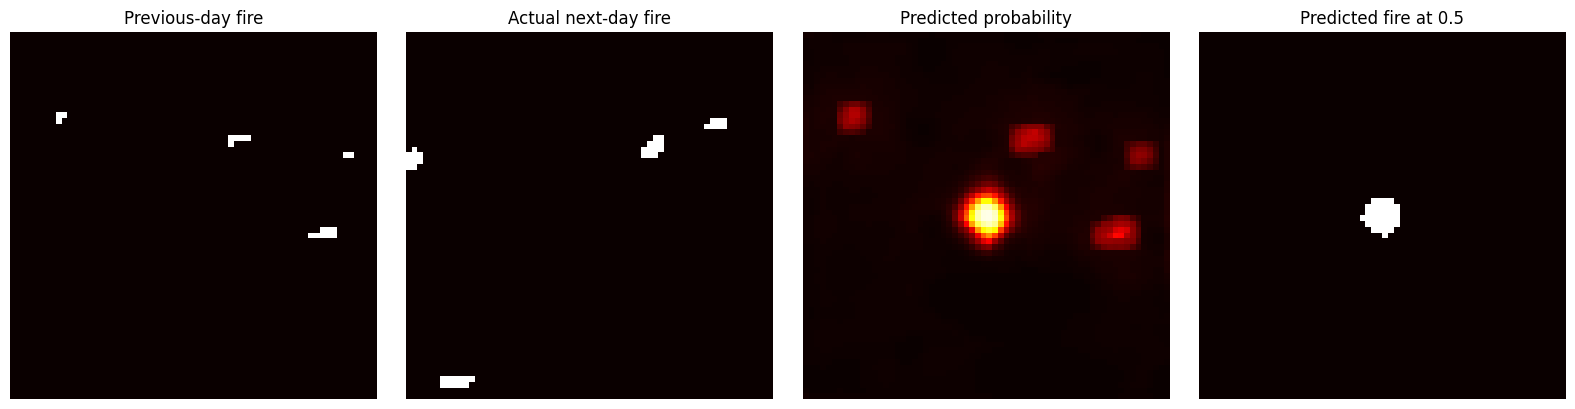

In [22]:
import matplotlib.pyplot as plt

# Pick a validation patch that contains at least one fire pixel.
sample_index = next(
    i
    for i, target in enumerate(val_loader.dataset.targets)
    if np.any(target == 1)
)

sample_input, sample_target, sample_mask = (
    val_loader.dataset[sample_index]
)

with torch.no_grad():
    sample_logits = model(
        sample_input.unsqueeze(0).to(device)
    )
    fire_probability = (
        torch.sigmoid(sample_logits)[0, 0].cpu().numpy()
    )

# The previous-day fire mask is normalized like the other inputs.
# Convert this channel back to its original values for display.
stats = NormalizationStats.load(STATS_PATH)
prev_channel = INPUT_FEATURES.index("PrevFireMask")

previous_fire = (
    sample_input[prev_channel].numpy() * stats.stds[prev_channel]
    + stats.means[prev_channel]
) > 0.5

valid_pixels = sample_mask[0].numpy() == 1
ground_truth = np.where(
    valid_pixels, sample_target[0].numpy(), np.nan
)
binary_prediction = np.where(
    valid_pixels, fire_probability >= THRESHOLD, np.nan
)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

images = [
    previous_fire,
    ground_truth,
    fire_probability,
    binary_prediction,
]
titles = [
    "Previous-day fire",
    "Actual next-day fire",
    "Predicted probability",
    "Predicted fire at 0.5",
]

for ax, image, title in zip(axes, images, titles):
    ax.imshow(image, cmap="hot", vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

# Save evidance of current model

In [ ]:
from pathlib import Path
import shutil
import json
import csv

run_dir = Path("../results/resnet_unet/run_001_baseline")
run_dir.mkdir(parents=True, exist_ok=True)

baseline_checkpoint = run_dir / "best.pt"

# Stop rather than overwrite evidence from an earlier attempt.
if baseline_checkpoint.exists():
    raise FileExistsError(f"Baseline already saved: {baseline_checkpoint}")

shutil.copy2(checkpoint_path, baseline_checkpoint)
shutil.copy2(
    STATS_PATH,
    run_dir / "normalization_stats.json",
)
shutil.copy2(
    "../shared/preprocessing.ipynb",
    run_dir / "preprocessing_snapshot.ipynb",
)

saved_baseline = torch.load(
    baseline_checkpoint,
    map_location="cpu",
    weights_only=True,
)

config = {
    "model": "ResNet34-UNet",
    "seed": SEED,
    "input_features": INPUT_FEATURES,
    "image_size": 64,
    "loss": "masked weighted BCE + 0.5 Dice",
    "pos_weight": float(pos_weight),
    "batch_size": BATCH_SIZE,
    "warmup_epochs": 3,
    "warmup_decoder_lr": 0.001,
    "finetune_max_epochs": 40,
    "finetune_encoder_lr": 0.00001,
    "finetune_decoder_lr": 0.0001,
    "selection_metric": "validation pixel AUPRC",
    "prediction_threshold": 0.5,
    "train_samples": len(train_loader.dataset),
    "validation_samples": len(val_loader.dataset),
    "test_samples": len(test_loader.dataset),
    "best_stage": saved_baseline["stage"],
    "best_stage_epoch": int(saved_baseline["epoch"]),
    "best_validation_auprc": float(saved_baseline["val_auprc"]),
    "training_seconds": (
        float(training_seconds) # type: ignore
        if "training_seconds" in globals()
        else None
    ),
}

with (run_dir / "config.json").open("x") as file:
    json.dump(config, file, indent=2)

print("Baseline checkpoint and settings saved in:", run_dir)

Baseline checkpoint and settings saved in: ../results/resnet_unet/run_001_baseline


In [24]:
if "history" not in globals() or not history["train_loss"]:
    print("History is no longer in memory. No CSV was created.")
else:
    number_of_epochs = len(history["train_loss"])

    assert all(
        len(history[key]) == number_of_epochs
        for key in ("stage", "val_loss", "val_auprc")
    )

    stage_epoch = {}

    with (run_dir / "training_history.csv").open(
        "x", newline=""
    ) as file:
        writer = csv.DictWriter(
            file,
            fieldnames=[
                "overall_epoch",
                "stage",
                "stage_epoch",
                "train_loss",
                "val_loss",
                "val_auprc",
            ],
        )
        writer.writeheader()

        for index in range(number_of_epochs):
            stage = history["stage"][index]
            stage_epoch[stage] = stage_epoch.get(stage, 0) + 1

            writer.writerow({
                "overall_epoch": index + 1,
                "stage": stage,
                "stage_epoch": stage_epoch[stage],
                "train_loss": history["train_loss"][index],
                "val_loss": history["val_loss"][index],
                "val_auprc": history["val_auprc"][index],
            })

    epochs = range(1, number_of_epochs + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, history["train_loss"], label="Training")
    axes[0].plot(epochs, history["val_loss"], label="Validation")
    axes[0].set(xlabel="Epoch", ylabel="Loss", title="Loss by epoch")
    axes[0].legend()

    axes[1].plot(epochs, history["val_auprc"])
    axes[1].set(
        xlabel="Epoch",
        ylabel="AUPRC",
        title="Validation AUPRC by epoch",
    )

    fig.tight_layout()
    fig.savefig(run_dir / "training_curves.png", dpi=160)
    plt.show()

    print("Saved training_history.csv and training_curves.png")

History is no longer in memory. No CSV was created.


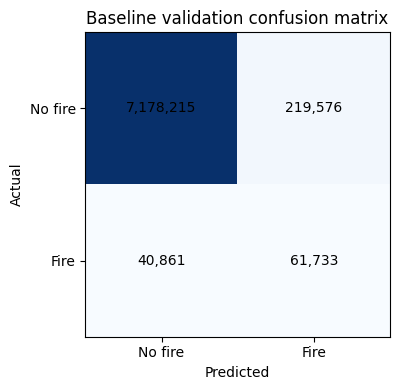

Saved validation_metrics.json and confusion_matrix.png


In [25]:
tp = 61733
fp = 219576
fn = 40861
tn = 7178215

precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * tp / (2 * tp + fp + fn)
iou = tp / (tp + fp + fn)
accuracy = (tp + tn) / (tp + fp + fn + tn)

baseline_metrics = {
    "split": "validation",
    "threshold": 0.5,
    "true_positive": tp,
    "false_positive": fp,
    "false_negative": fn,
    "true_negative": tn,
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "fire_iou": iou,
    "accuracy": accuracy,
    "pixel_auprc": float(saved_baseline["val_auprc"]),
}

with (run_dir / "validation_metrics.json").open("x") as file:
    json.dump(baseline_metrics, file, indent=2)

confusion = np.array([[tn, fp], [fn, tp]])

fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(confusion, cmap="Blues")

ax.set_xticks([0, 1], labels=["No fire", "Fire"])
ax.set_yticks([0, 1], labels=["No fire", "Fire"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Baseline validation confusion matrix")

for row in range(2):
    for column in range(2):
        ax.text(
            column, row, f"{confusion[row, column]:,}",
            ha="center", va="center",
        )

fig.tight_layout()
fig.savefig(run_dir / "confusion_matrix.png", dpi=160)
plt.show()

print("Saved validation_metrics.json and confusion_matrix.png")

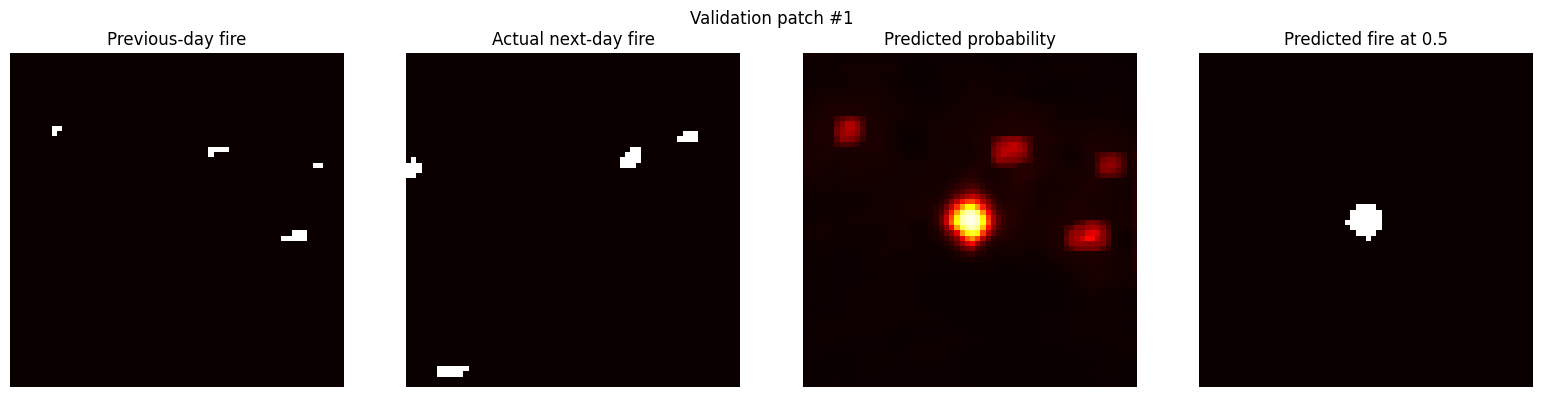

Saved validation_example.png
Validation example index: 1


In [ ]:
model.load_state_dict(saved_baseline["model_state_dict"])
model.to(device)
model.eval()

example_index = next(
    index
    for index, target in enumerate(val_loader.dataset.targets)
    if np.any(target == 1)
)

example_input, example_target, example_mask = (
    val_loader.dataset[example_index]
)

with torch.no_grad():
    logits = model(example_input.unsqueeze(0).to(device))
    probability = torch.sigmoid(logits)[0, 0].cpu().numpy()

stats = NormalizationStats.load(STATS_PATH) # type: ignore
prev_index = INPUT_FEATURES.index("PrevFireMask") # type: ignore

previous_fire = (
    example_input[prev_index].numpy() * stats.stds[prev_index]
    + stats.means[prev_index]
) > 0.5

valid = example_mask[0].numpy() == 1
actual_fire = np.where(
    valid, example_target[0].numpy(), np.nan
)
predicted_fire = np.where(
    valid, probability >= 0.5, np.nan
)

images = [
    previous_fire,
    actual_fire,
    probability,
    predicted_fire,
]
titles = [
    "Previous-day fire",
    "Actual next-day fire",
    "Predicted probability",
    "Predicted fire at 0.5",
]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, image, title in zip(axes, images, titles):
    ax.imshow(image, cmap="hot", vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis("off")

fig.suptitle(f"Validation patch #{example_index}")
fig.tight_layout()
fig.savefig(run_dir / "validation_example.png", dpi=160)
plt.show()

print("Saved validation_example.png")
print("Validation example index:", example_index)

## Collect validation probabilities

In [27]:
from pathlib import Path
from torch.utils.data import DataLoader
import csv
import json

run_dir = Path("../results/resnet_unet/run_001_baseline")
baseline_checkpoint = run_dir / "best.pt"
assert baseline_checkpoint.exists()

saved = torch.load(
    baseline_checkpoint,
    map_location=device,
    weights_only=True,
)
model.load_state_dict(saved["model_state_dict"])
model.to(device)
model.eval()

validation_batches = DataLoader(
    val_loader.dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
)

label_parts = []
probability_parts = []

with torch.no_grad():
    for batch_inputs, batch_targets, batch_mask in validation_batches:
        logits = model(batch_inputs.to(device))
        probabilities = torch.sigmoid(logits).cpu()

        valid = batch_mask.bool()

        label_parts.append(
            (batch_targets[valid] == 1).numpy().astype(np.uint8)
        )
        probability_parts.append(
            probabilities[valid].numpy().astype(np.float32)
        )

labels = np.concatenate(label_parts)
probabilities = np.concatenate(probability_parts)

print("Valid validation pixels:", len(labels))
print("Fire pixels:", int(labels.sum()))

Valid validation pixels: 7500385
Fire pixels: 102594


## Compare thresholds and save the CSV

In [28]:
rows = []
fire_pixels = labels == 1
total_fire = int(fire_pixels.sum())
total_no_fire = len(labels) - total_fire

for threshold in np.round(np.arange(0.05, 1.00, 0.05), 2):
    predicted_fire = probabilities >= threshold

    tp = int(np.count_nonzero(predicted_fire & fire_pixels))
    fp = int(np.count_nonzero(predicted_fire)) - tp
    fn = total_fire - tp
    tn = total_no_fire - fp

    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * tp / (2 * tp + fp + fn) if 2 * tp + fp + fn else 0.0
    iou = tp / (tp + fp + fn) if tp + fp + fn else 0.0

    rows.append({
        "threshold": float(threshold),
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "fire_iou": iou,
    })

baseline_row = next(
    row for row in rows if row["threshold"] == 0.5
)
best_row = max(rows, key=lambda row: row["f1"])

# Check that we really evaluated the preserved baseline.
assert abs(baseline_row["f1"] - 0.3216) < 0.005, (
    "The result at 0.5 does not match your earlier baseline. "
    "Check the checkpoint and preprocessing before proceeding."
)

csv_path = run_dir / "validation_thresholds.csv"

with csv_path.open("x", newline="") as file:
    writer = csv.DictWriter(file, fieldnames=rows[0].keys())
    writer.writeheader()
    writer.writerows(rows)

print("At threshold 0.5:")
print(baseline_row)
print("\nHighest validation F1 in this search:")
print(best_row)
print("\nSaved:", csv_path)

At threshold 0.5:
{'threshold': 0.5, 'tp': 61733, 'fp': 219576, 'fn': 40861, 'tn': 7178215, 'precision': 0.2194490755717023, 'recall': 0.6017213482269919, 'f1': 0.3216072810058791, 'fire_iou': 0.19161622745755347}

Highest validation F1 in this search:
{'threshold': 0.75, 'tp': 47997, 'fp': 128492, 'fn': 54597, 'tn': 7269299, 'precision': 0.271954626067347, 'recall': 0.46783437627931457, 'f1': 0.343962190459469, 'fire_iou': 0.20770189453277135}

Saved: ../results/resnet_unet/run_001_baseline/validation_thresholds.csv


## Save figures and the candidate threshold

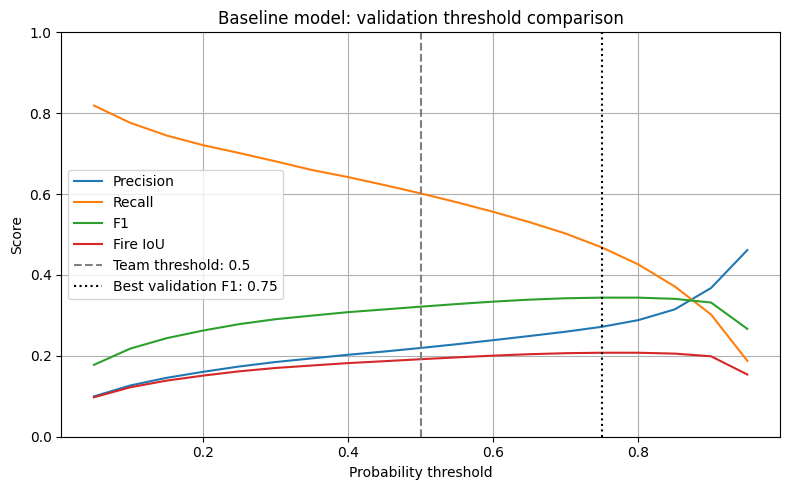

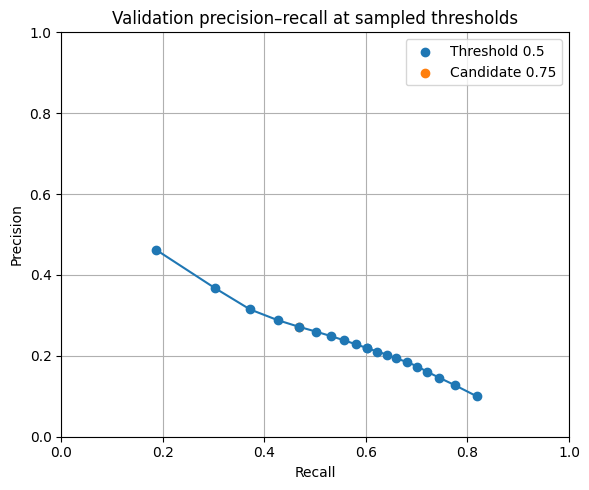

Saved both plots and threshold_selection.json


In [29]:
import matplotlib.pyplot as plt

threshold_values = [row["threshold"] for row in rows]
precision_values = [row["precision"] for row in rows]
recall_values = [row["recall"] for row in rows]
f1_values = [row["f1"] for row in rows]
iou_values = [row["fire_iou"] for row in rows]

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(threshold_values, precision_values, label="Precision")
ax.plot(threshold_values, recall_values, label="Recall")
ax.plot(threshold_values, f1_values, label="F1")
ax.plot(threshold_values, iou_values, label="Fire IoU")
ax.axvline(0.5, color="gray", linestyle="--", label="Team threshold: 0.5")
ax.axvline(
    best_row["threshold"],
    color="black",
    linestyle=":",
    label=f"Best validation F1: {best_row['threshold']:.2f}",
)

ax.set_xlabel("Probability threshold")
ax.set_ylabel("Score")
ax.set_title("Baseline model: validation threshold comparison")
ax.set_ylim(0, 1)
ax.grid(True)
ax.legend()

fig.tight_layout()
fig.savefig(run_dir / "threshold_curves.png", dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))

ax.plot(recall_values, precision_values, marker="o")
ax.scatter(
    baseline_row["recall"],
    baseline_row["precision"],
    label="Threshold 0.5",
)
ax.scatter(
    best_row["recall"],
    best_row["precision"],
    label=f"Candidate {best_row['threshold']:.2f}",
)

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Validation precision–recall at sampled thresholds")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(True)
ax.legend()

fig.tight_layout()
fig.savefig(run_dir / "precision_recall_curve.png", dpi=160)
plt.show()

selection = {
    "selection_split": "validation",
    "selection_metric": "fire_pixel_f1",
    "team_comparison_threshold": 0.5,
    "candidate_threshold": best_row["threshold"],
    "metrics_at_0_5": baseline_row,
    "metrics_at_candidate": best_row,
    "checkpoint_validation_auprc": float(saved["val_auprc"]),
}

with (run_dir / "threshold_selection.json").open("x") as file:
    json.dump(selection, file, indent=2)

print("Saved both plots and threshold_selection.json")

In [30]:
from pathlib import Path
import csv
import json

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

run_dir = Path("../results/resnet_unet/run_001_baseline")
run_dir.mkdir(parents=True, exist_ok=True)

# Use the saved baseline, even if another model was loaded later.
checkpoint = torch.load(
    run_dir / "best.pt",
    map_location=device,
    weights_only=True
)
weights = checkpoint.get("model_state_dict", checkpoint)
model.load_state_dict(weights)
model.to(device)
model.eval()

case_loader = DataLoader(
    val_loader.dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0
)

def count_pixels(probability, target, threshold):
    """Count valid pixels for one validation image."""
    valid = target >= 0          # -1 means the target is unknown
    fire = target > 0.5
    predicted_fire = probability >= threshold

    tp = int(np.sum(valid & fire & predicted_fire))
    fp = int(np.sum(valid & ~fire & predicted_fire))
    fn = int(np.sum(valid & fire & ~predicted_fire))
    tn = int(np.sum(valid & ~fire & ~predicted_fire))
    return tp, fp, fn, tn

def fire_f1(tp, fp, fn):
    """Return F1; use 0 when there are no correct fire predictions."""
    denominator = 2 * tp + fp + fn
    return 2 * tp / denominator if denominator else 0.0

In [33]:
case_rows = []
image_index = 0

with torch.no_grad():
    for inputs, targets, valid_mask in case_loader:
        probabilities = torch.sigmoid(model(inputs.to(device)))
        probabilities = probabilities.cpu().numpy()
        targets = targets.cpu().numpy()

        for probability, target in zip(probabilities, targets):
            # Model and target each have one channel: [1, 64, 64].
            probability = probability[0]
            target = target[0]

            tp50, fp50, fn50, tn50 = count_pixels(
                probability, target, 0.50
            )
            tp75, fp75, fn75, tn75 = count_pixels(
                probability, target, 0.75
            )

            case_rows.append({
                "index": image_index,
                "valid_pixels": tp50 + fp50 + fn50 + tn50,
                "fire_pixels": tp50 + fn50,
                "tp_050": tp50,
                "fp_050": fp50,
                "fn_050": fn50,
                "tn_050": tn50,
                "f1_050": fire_f1(tp50, fp50, fn50),
                "tp_075": tp75,
                "fp_075": fp75,
                "fn_075": fn75,
                "tn_075": tn75,
                "f1_075": fire_f1(tp75, fp75, fn75),
            })
            image_index += 1

# Confirm we examined the same baseline and validation split as Phase B.
totals_050 = {
    name: sum(row[f"{name}_050"] for row in case_rows)
    for name in ("tp", "fp", "fn", "tn")
}
print("Validation images:", len(case_rows))
print("Totals at 0.50:", totals_050)

expected_050 = {
    "tp": 61733, "fp": 219576,
    "fn": 40861, "tn": 7178215
}
if totals_050 != expected_050:
    raise ValueError(
        "Counts differ from Phase B. Check the checkpoint, validation "
        "dataset, and whether validation augmentation is disabled."
    )

Validation images: 1877
Totals at 0.50: {'tp': 61733, 'fp': 219576, 'fn': 40861, 'tn': 7178215}


In [34]:
csv_path = run_dir / "validation_case_summary.csv"

with csv_path.open("w", newline="") as file:
    writer = csv.DictWriter(file, fieldnames=case_rows[0].keys())
    writer.writeheader()
    writer.writerows(case_rows)

fire_cases = [row for row in case_rows if row["fire_pixels"] > 0]
no_fire_cases = [row for row in case_rows if row["fire_pixels"] == 0]

summary = {
    "validation_images": len(case_rows),
    "images_with_fire": len(fire_cases),
    "images_without_fire": len(no_fire_cases),
    "no_fire_images_with_false_alarms_050": sum(
        row["fp_050"] > 0 for row in no_fire_cases
    ),
    "no_fire_images_with_false_alarms_075": sum(
        row["fp_075"] > 0 for row in no_fire_cases
    ),
    "fire_images_with_missed_pixels_075": sum(
        row["fn_075"] > 0 for row in fire_cases
    ),
}

with (run_dir / "validation_error_summary.json").open("w") as file:
    json.dump(summary, file, indent=2)

# Sort each group, then avoid showing the same image twice.
groups = [
    ("Good fire detection",
     sorted(fire_cases, key=lambda row: row["f1_075"], reverse=True)),
    ("Most missed fire pixels",
     sorted(fire_cases, key=lambda row: row["fn_075"], reverse=True)),
    ("Most false fire pixels on a fire image",
     sorted(fire_cases, key=lambda row: row["fp_075"], reverse=True)),
    ("False alarm on a no-fire image",
     sorted(no_fire_cases, key=lambda row: row["fp_075"], reverse=True)),
]

chosen = []
used_indices = set()

for category, candidates in groups:
    for row in candidates:
        # Skip cases that do not actually show this type of error.
        if category == "Most missed fire pixels" and row["fn_075"] == 0:
            continue
        if "false" in category.lower() and row["fp_075"] == 0:
            continue
        if row["index"] in used_indices:
            continue

        chosen.append({"category": category, **row})
        used_indices.add(row["index"])
        break

with (run_dir / "selected_validation_cases.csv").open("w", newline="") as file:
    writer = csv.DictWriter(file, fieldnames=chosen[0].keys())
    writer.writeheader()
    writer.writerows(chosen)

print(json.dumps(summary, indent=2))
print("Selected image indices:", [row["index"] for row in chosen])
print("Saved:", csv_path)

{
  "validation_images": 1877,
  "images_with_fire": 1673,
  "images_without_fire": 204,
  "no_fire_images_with_false_alarms_050": 175,
  "no_fire_images_with_false_alarms_075": 157,
  "fire_images_with_missed_pixels_075": 1377
}
Selected image indices: [1614, 1728, 158, 1016]
Saved: ../results/resnet_unet/run_001_baseline/validation_case_summary.csv


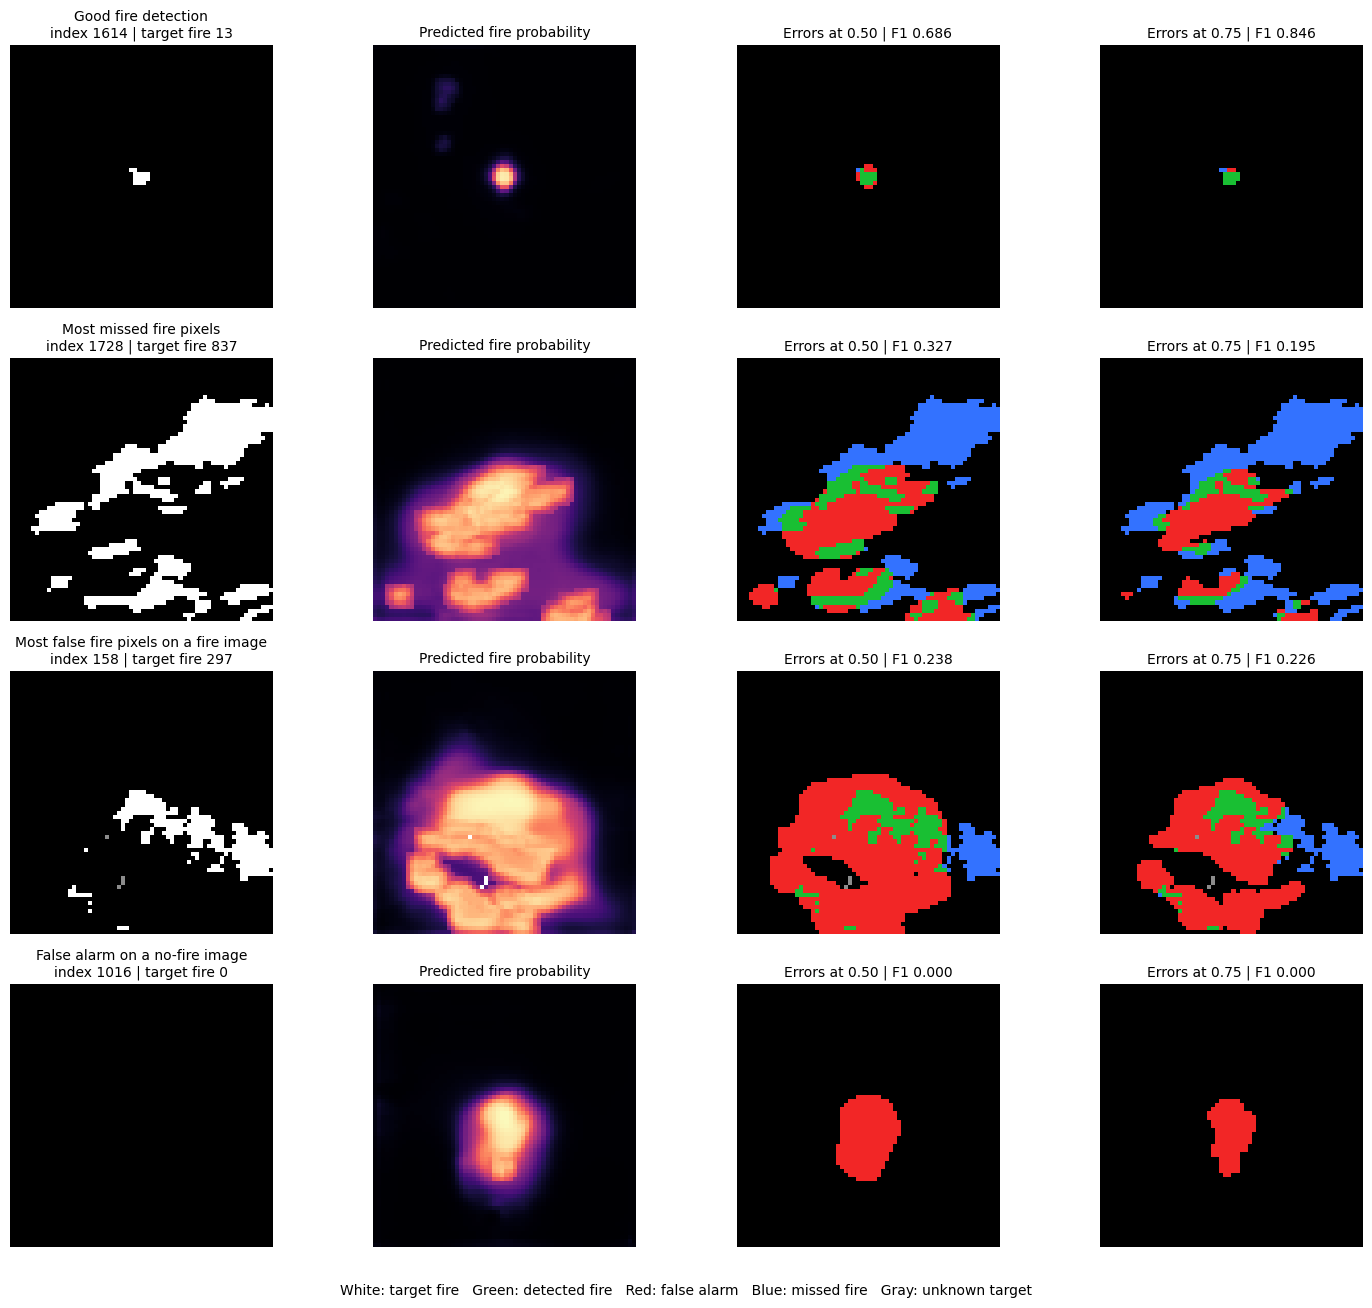

Saved: ../results/resnet_unet/run_001_baseline/validation_error_gallery.png


In [35]:
def error_image(probability, target, threshold):
    """Make an RGB picture of correct and incorrect fire predictions."""
    valid = target >= 0
    fire = target > 0.5
    predicted = probability >= threshold

    picture = np.zeros((*target.shape, 3), dtype=np.float32)
    picture[~valid] = (0.55, 0.55, 0.55)
    picture[valid & fire & predicted] = (0.10, 0.75, 0.20)   # TP
    picture[valid & ~fire & predicted] = (0.95, 0.15, 0.15)  # FP
    picture[valid & fire & ~predicted] = (0.20, 0.45, 1.00)  # FN
    return picture

wanted = {row["index"] for row in chosen}
pictures = {}
image_index = 0

# A second pass loads predictions only for the few selected images.
with torch.no_grad():
    for inputs, targets, valid_mask in case_loader:
        batch_indices = range(image_index, image_index + len(inputs))

        if any(index in wanted for index in batch_indices):
            probabilities = torch.sigmoid(model(inputs.to(device)))
            probabilities = probabilities.cpu().numpy()
            targets_np = targets.cpu().numpy()

            for position, index in enumerate(batch_indices):
                if index in wanted:
                    pictures[index] = (
                        probabilities[position, 0],
                        targets_np[position, 0]
                    )

        image_index += len(inputs)

fig, axes = plt.subplots(
    len(chosen), 4,
    figsize=(15, 3.3 * len(chosen)),
    squeeze=False
)

for row_number, case in enumerate(chosen):
    probability, target = pictures[case["index"]]
    valid = target >= 0

    target_picture = np.zeros((*target.shape, 3), dtype=np.float32)
    target_picture[~valid] = (0.55, 0.55, 0.55)
    target_picture[valid & (target > 0.5)] = (1, 1, 1)

    axes[row_number, 0].imshow(target_picture)
    axes[row_number, 1].imshow(
        np.ma.masked_where(~valid, probability),
        cmap="magma", vmin=0, vmax=1
    )
    axes[row_number, 1].set_facecolor("0.55")
    axes[row_number, 2].imshow(error_image(probability, target, 0.50))
    axes[row_number, 3].imshow(error_image(probability, target, 0.75))

    titles = (
        f"{case['category']}\nindex {case['index']} | target fire {case['fire_pixels']}",
        "Predicted fire probability",
        f"Errors at 0.50 | F1 {case['f1_050']:.3f}",
        f"Errors at 0.75 | F1 {case['f1_075']:.3f}",
    )
    for axis, title in zip(axes[row_number], titles):
        axis.set_title(title, fontsize=10)
        axis.axis("off")

fig.text(
    0.5, 0.015,
    "White: target fire   Green: detected fire   Red: false alarm   "
    "Blue: missed fire   Gray: unknown target",
    ha="center", fontsize=10
)
plt.tight_layout(rect=(0, 0.04, 1, 1))

figure_path = run_dir / "validation_error_gallery.png"
fig.savefig(figure_path, dpi=180, bbox_inches="tight")
plt.show()

print("Saved:", figure_path)

# Train with a higher encoder learning rate

## Prepare the new run

In [36]:
from pathlib import Path
import csv
import json
import shutil

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

baseline_dir = Path("../results/resnet_unet/run_001_baseline")
run_dir = Path("../results/resnet_unet/run_002_encoder_lr")
run_dir.mkdir(parents=True, exist_ok=True)

# Always begin this experiment from the saved baseline.
checkpoint = torch.load(
    baseline_dir / "best.pt",
    map_location=device,
    weights_only=True
)
weights = checkpoint.get("model_state_dict", checkpoint)
model.load_state_dict(weights)
model.to(device)

# Phase 5 initially froze the encoder. Make every layer trainable here.
for parameter in model.parameters():
    parameter.requires_grad = True

train_batches = DataLoader(
    train_loader.dataset, batch_size=8, shuffle=True, num_workers=0
)
val_batches = DataLoader(
    val_loader.dataset, batch_size=8, shuffle=False, num_workers=0
)

# Separate pretrained ResNet parameters from decoder parameters.
encoder_parameters = list(model.encoder.parameters())
encoder_ids = {id(parameter) for parameter in encoder_parameters}
decoder_parameters = [
    parameter for parameter in model.parameters()
    if id(parameter) not in encoder_ids
]

assert encoder_parameters and decoder_parameters
assert abs(float(pos_weight) - 20.0) < 0.01, (
    "Expected the updated preprocessing with pos_weight capped at 20."
)

optimizer = torch.optim.AdamW([
    {"params": encoder_parameters, "lr": 3e-5},
    {"params": decoder_parameters, "lr": 1e-4},
])

config = {
    "experiment": "Continue baseline with encoder LR 3e-5",
    "starting_checkpoint": str(baseline_dir / "best.pt"),
    "encoder_lr": 3e-5,
    "decoder_lr": 1e-4,
    "batch_size": 8,
    "pos_weight": float(pos_weight),
    "loss": "masked weighted BCE + 0.5 Dice",
    "optimizer": "AdamW",
    "max_epochs": 12,
    "early_stopping_patience": 5,
    "checkpoint_selection": "validation average precision",
    "validation_thresholds_reported": [0.50, 0.75],
}

with (run_dir / "config.json").open("w") as file:
    json.dump(config, file, indent=2)

print("Run folder:", run_dir)
print("Encoder parameters:", len(encoder_parameters))
print("Other parameters:", len(decoder_parameters))

Run folder: ../results/resnet_unet/run_002_encoder_lr
Encoder parameters: 108
Other parameters: 22


## loss and validation metric

In [37]:
def segmentation_loss(logits, targets, valid_mask):
    """Weighted BCE plus half a Dice loss, using known target pixels only."""
    targets = targets.clamp(0, 1)  # Replace unknown -1 before calculating BCE

    bce_pixels = F.binary_cross_entropy_with_logits(
        logits,
        targets,
        pos_weight=torch.tensor(20.0, device=logits.device),
        reduction="none"
    )
    bce = (bce_pixels * valid_mask).sum() / valid_mask.sum().clamp_min(1)

    probabilities = torch.sigmoid(logits)
    intersection = (probabilities * targets * valid_mask).sum()
    predicted_total = (probabilities * valid_mask).sum()
    target_total = (targets * valid_mask).sum()

    dice = (2 * intersection + 1) / (
        predicted_total + target_total + 1
    )
    return bce + 0.5 * (1 - dice)


def average_precision_numpy(labels, scores):
    """Average precision over all valid validation pixels."""
    order = np.argsort(-scores, kind="stable")
    sorted_scores = scores[order]
    sorted_labels = labels[order].astype(np.int64)

    # Take one precision value after each group of equal scores.
    ends = np.r_[
        np.flatnonzero(sorted_scores[1:] != sorted_scores[:-1]) + 1,
        len(sorted_scores)
    ]
    true_positives = np.cumsum(sorted_labels)[ends - 1]
    total_positives = true_positives[-1]

    if total_positives == 0:
        raise ValueError("Validation set has no known fire pixels.")

    precision = true_positives / ends
    recall = true_positives / total_positives
    return float(np.sum(np.diff(np.r_[0, recall]) * precision))


def threshold_metrics(labels, scores, threshold):
    predicted = scores >= threshold
    fire = labels == 1

    tp = int(np.sum(predicted & fire))
    fp = int(np.sum(predicted & ~fire))
    fn = int(np.sum(~predicted & fire))
    tn = int(np.sum(~predicted & ~fire))

    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * tp / (2 * tp + fp + fn) if 2 * tp + fp + fn else 0.0

    return {
        "tp": tp, "fp": fp, "fn": fn, "tn": tn,
        "precision": precision, "recall": recall, "f1": f1
    }

## One training epoch and one validation pass

In [38]:
def train_one_epoch():
    model.train()
    loss_total = 0.0
    image_total = 0

    for inputs, targets, valid_mask in train_batches:
        inputs = inputs.to(device)
        targets = targets.to(device)
        valid_mask = valid_mask.to(device)

        optimizer.zero_grad()
        logits = model(inputs)
        loss = segmentation_loss(logits, targets, valid_mask)
        loss.backward()
        optimizer.step()

        loss_total += loss.item() * len(inputs)
        image_total += len(inputs)

    return loss_total / image_total


def validate():
    model.eval()
    loss_total = 0.0
    image_total = 0
    all_labels = []
    all_scores = []

    with torch.no_grad():
        for inputs, targets, valid_mask in val_batches:
            inputs = inputs.to(device)
            targets = targets.to(device)
            valid_mask = valid_mask.to(device)

            logits = model(inputs)
            loss = segmentation_loss(logits, targets, valid_mask)

            loss_total += loss.item() * len(inputs)
            image_total += len(inputs)

            # Keep only pixels whose target is known.
            known = valid_mask > 0.5
            scores = torch.sigmoid(logits)[known].cpu().numpy()
            labels = (targets[known] > 0.5).cpu().numpy()

            all_scores.append(scores)
            all_labels.append(labels)

    scores = np.concatenate(all_scores)
    labels = np.concatenate(all_labels)

    return {
        "val_loss": loss_total / image_total,
        "val_auprc": average_precision_numpy(labels, scores),
        "at_050": threshold_metrics(labels, scores, 0.50),
        "at_075": threshold_metrics(labels, scores, 0.75),
    }

## train and save evidence

In [39]:
starting_result = validate()
starting_f1 = starting_result["at_050"]["f1"]

print("Starting validation F1 at 0.50:", round(starting_f1, 4))
print("Starting validation AUPRC:", round(starting_result["val_auprc"], 4))

if abs(starting_f1 - 0.3216072810) > 0.002:
    raise ValueError(
        "The starting model does not match the baseline results. "
        "Check the checkpoint and validation dataset."
    )

with (run_dir / "starting_validation_metrics.json").open("w") as file:
    json.dump(starting_result, file, indent=2)

# If training makes no improvement, this remains the best checkpoint.
shutil.copy2(baseline_dir / "best.pt", run_dir / "best.pt")

history = []
best_auprc = starting_result["val_auprc"]
best_epoch = 0
epochs_without_improvement = 0

for epoch in range(1, 13):
    training_loss = train_one_epoch()
    result = validate()

    row = {
        "epoch": epoch,
        "train_loss": training_loss,
        "val_loss": result["val_loss"],
        "val_auprc": result["val_auprc"],
        "val_f1_050": result["at_050"]["f1"],
        "val_f1_075": result["at_075"]["f1"],
    }
    history.append(row)

    # Write the CSV now, so completed epochs survive an interruption.
    with (run_dir / "training_history.csv").open("w", newline="") as file:
        writer = csv.DictWriter(file, fieldnames=row.keys())
        writer.writeheader()
        writer.writerows(history)

    if result["val_auprc"] > best_auprc:
        best_auprc = result["val_auprc"]
        best_epoch = epoch
        epochs_without_improvement = 0
        torch.save(model.state_dict(), run_dir / "best.pt")

        with (run_dir / "best_validation_metrics.json").open("w") as file:
            json.dump({"epoch": epoch, **result}, file, indent=2)
    else:
        epochs_without_improvement += 1

    print(
        f"Epoch {epoch:02d} | "
        f"train loss {training_loss:.4f} | "
        f"val loss {result['val_loss']:.4f} | "
        f"AUPRC {result['val_auprc']:.4f} | "
        f"F1@0.50 {result['at_050']['f1']:.4f} | "
        f"F1@0.75 {result['at_075']['f1']:.4f}"
    )

    if epochs_without_improvement >= 5:
        print("Stopped early: validation AUPRC did not improve for 5 epochs.")
        break

print("Best epoch:", best_epoch)
print("Best validation AUPRC:", round(best_auprc, 4))

if best_epoch == 0:
    print("This experiment did not improve on the starting checkpoint.")

Starting validation F1 at 0.50: 0.3216
Starting validation AUPRC: 0.2818
Epoch 01 | train loss 0.5973 | val loss 0.8232 | AUPRC 0.2755 | F1@0.50 0.3210 | F1@0.75 0.3399
Epoch 02 | train loss 0.5961 | val loss 0.7988 | AUPRC 0.2780 | F1@0.50 0.3176 | F1@0.75 0.3409
Epoch 03 | train loss 0.5935 | val loss 0.8285 | AUPRC 0.2799 | F1@0.50 0.3271 | F1@0.75 0.3436
Epoch 04 | train loss 0.5920 | val loss 0.8365 | AUPRC 0.2711 | F1@0.50 0.3168 | F1@0.75 0.3381
Epoch 05 | train loss 0.5913 | val loss 0.8383 | AUPRC 0.2799 | F1@0.50 0.3270 | F1@0.75 0.3468
Stopped early: validation AUPRC did not improve for 5 epochs.
Best epoch: 0
Best validation AUPRC: 0.2818
This experiment did not improve on the starting checkpoint.


## save the training curves and final comparison

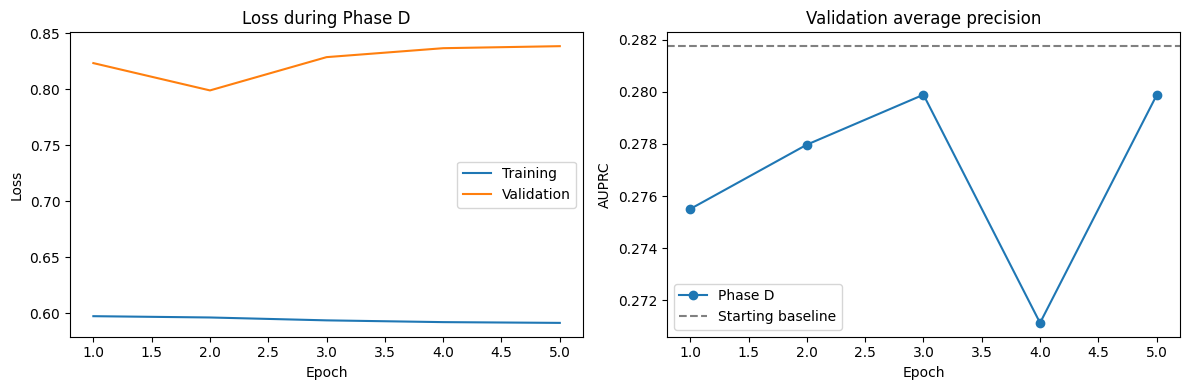

{
  "starting_auprc": 0.28175205460094155,
  "best_auprc": 0.28175205460094155,
  "best_epoch": 0,
  "starting_at_050": {
    "tp": 61733,
    "fp": 219576,
    "fn": 40861,
    "tn": 7178215,
    "precision": 0.2194490755717023,
    "recall": 0.6017213482269919,
    "f1": 0.3216072810058791
  },
  "best_at_050": {
    "tp": 61733,
    "fp": 219576,
    "fn": 40861,
    "tn": 7178215,
    "precision": 0.2194490755717023,
    "recall": 0.6017213482269919,
    "f1": 0.3216072810058791
  },
  "starting_at_075": {
    "tp": 47997,
    "fp": 128492,
    "fn": 54597,
    "tn": 7269299,
    "precision": 0.271954626067347,
    "recall": 0.46783437627931457,
    "f1": 0.343962190459469
  },
  "best_at_075": {
    "tp": 47997,
    "fp": 128492,
    "fn": 54597,
    "tn": 7269299,
    "precision": 0.271954626067347,
    "recall": 0.46783437627931457,
    "f1": 0.343962190459469
  }
}
Saved evidence in: ../results/resnet_unet/run_002_encoder_lr


In [40]:
epochs = [row["epoch"] for row in history]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(
    epochs, [row["train_loss"] for row in history], label="Training"
)
axes[0].plot(
    epochs, [row["val_loss"] for row in history], label="Validation"
)
axes[0].set_title("Loss during Phase D")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(
    epochs, [row["val_auprc"] for row in history],
    marker="o", label="Phase D"
)
axes[1].axhline(
    starting_result["val_auprc"],
    linestyle="--", color="gray", label="Starting baseline"
)
axes[1].set_title("Validation average precision")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("AUPRC")
axes[1].legend()

plt.tight_layout()
plt.savefig(run_dir / "training_curves.png", dpi=180)
plt.show()

# Evaluate the best saved weights, not whichever epoch ran last.
best_checkpoint = torch.load(
    run_dir / "best.pt", map_location=device, weights_only=True
)
best_weights = best_checkpoint.get("model_state_dict", best_checkpoint)
model.load_state_dict(best_weights)
final_result = validate()

comparison = {
    "starting_auprc": starting_result["val_auprc"],
    "best_auprc": final_result["val_auprc"],
    "best_epoch": best_epoch,
    "starting_at_050": starting_result["at_050"],
    "best_at_050": final_result["at_050"],
    "starting_at_075": starting_result["at_075"],
    "best_at_075": final_result["at_075"],
}

with (run_dir / "baseline_comparison.json").open("w") as file:
    json.dump(comparison, file, indent=2)

print(json.dumps(comparison, indent=2))
print("Saved evidence in:", run_dir)

# Test a lower training loss weight

In [41]:
import csv
from pathlib import Path

phase_d_csv = Path(
    "../results/resnet_unet/run_002_encoder_lr/training_history.csv"
)

with phase_d_csv.open() as file:
    phase_d_rows = list(csv.DictReader(file))

for metric in ("val_auprc", "val_f1_050", "val_f1_075"):
    best_row = max(phase_d_rows, key=lambda row: float(row[metric]))
    print(
        metric,
        "| best epoch:", best_row["epoch"],
        "| value:", round(float(best_row[metric]), 4)
    )

val_auprc | best epoch: 3 | value: 0.2799
val_f1_050 | best epoch: 3 | value: 0.3271
val_f1_075 | best epoch: 5 | value: 0.3468


## reset to the baseline and create a separate run

In [42]:
import json
import shutil
import numpy as np
import torch

baseline_dir = Path("../results/resnet_unet/run_001_baseline")
run_dir = Path("../results/resnet_unet/run_003_loss_weight_10")
run_dir.mkdir(parents=True, exist_ok=True)

torch.manual_seed(42)
np.random.seed(42)

checkpoint = torch.load(
    baseline_dir / "best.pt",
    map_location=device,
    weights_only=True
)
weights = checkpoint.get("model_state_dict", checkpoint)
model.load_state_dict(weights)
model.to(device)

for parameter in model.parameters():
    parameter.requires_grad = True

encoder_parameters = list(model.encoder.parameters())
encoder_ids = {id(parameter) for parameter in encoder_parameters}
decoder_parameters = [
    parameter for parameter in model.parameters()
    if id(parameter) not in encoder_ids
]

# Return to the baseline learning rates. The loss weight is our experiment.
optimizer = torch.optim.AdamW([
    {"params": encoder_parameters, "lr": 1e-5},
    {"params": decoder_parameters, "lr": 1e-4},
])

LOSS_POS_WEIGHT = 10.0

config = {
    "experiment": "Continue baseline with loss positive weight 10",
    "starting_checkpoint": str(baseline_dir / "best.pt"),
    "preprocessing_positive_weight": float(pos_weight),
    "training_loss_positive_weight": LOSS_POS_WEIGHT,
    "dice_multiplier": 0.5,
    "encoder_lr": 1e-5,
    "decoder_lr": 1e-4,
    "batch_size": 8,
    "max_epochs": 12,
    "early_stopping_patience": 5,
    "checkpoint_metrics": ["validation AUPRC", "validation F1 at 0.50"],
}

with (run_dir / "config.json").open("w") as file:
    json.dump(config, file, indent=2)

print("New run:", run_dir)
print("Preprocessing weight:", pos_weight)
print("Weight used in this experiment's loss:", LOSS_POS_WEIGHT)

New run: ../results/resnet_unet/run_003_loss_weight_10
Preprocessing weight: 20.0
Weight used in this experiment's loss: 10.0


## replace the loss function

In [43]:
import torch.nn.functional as F

def segmentation_loss(logits, targets, valid_mask):
    """Weighted BCE plus half a Dice loss on known pixels."""
    targets = targets.clamp(0, 1)

    bce_pixels = F.binary_cross_entropy_with_logits(
        logits,
        targets,
        pos_weight=torch.tensor(
            LOSS_POS_WEIGHT, device=logits.device
        ),
        reduction="none"
    )
    bce = (bce_pixels * valid_mask).sum() / valid_mask.sum().clamp_min(1)

    probabilities = torch.sigmoid(logits)
    intersection = (probabilities * targets * valid_mask).sum()
    predicted_total = (probabilities * valid_mask).sum()
    target_total = (targets * valid_mask).sum()

    dice = (2 * intersection + 1) / (
        predicted_total + target_total + 1
    )
    return bce + 0.5 * (1 - dice)

## train and keep both useful checkpoints

In [44]:
starting_result = validate()

if abs(starting_result["at_050"]["f1"] - 0.3216072810) > 0.002:
    raise ValueError("Starting model or validation data differs from baseline.")

with (run_dir / "starting_validation_metrics.json").open("w") as file:
    json.dump(starting_result, file, indent=2)

# Both checkpoints initially contain the baseline.
shutil.copy2(baseline_dir / "best.pt", run_dir / "best_auprc.pt")
shutil.copy2(baseline_dir / "best.pt", run_dir / "best_f1_050.pt")

best_auprc = starting_result["val_auprc"]
best_f1 = starting_result["at_050"]["f1"]
best_auprc_epoch = 0
best_f1_epoch = 0
epochs_without_improvement = 0
history_e = []

for epoch in range(1, 13):
    train_loss = train_one_epoch()
    result = validate()

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": result["val_loss"],
        "val_auprc": result["val_auprc"],
        "val_f1_050": result["at_050"]["f1"],
        "val_f1_075": result["at_075"]["f1"],
    }
    history_e.append(row)

    with (run_dir / "training_history.csv").open("w", newline="") as file:
        writer = csv.DictWriter(file, fieldnames=row.keys())
        writer.writeheader()
        writer.writerows(history_e)

    improved = False

    if result["val_auprc"] > best_auprc:
        best_auprc = result["val_auprc"]
        best_auprc_epoch = epoch
        torch.save(model.state_dict(), run_dir / "best_auprc.pt")
        improved = True

    if result["at_050"]["f1"] > best_f1:
        best_f1 = result["at_050"]["f1"]
        best_f1_epoch = epoch
        torch.save(model.state_dict(), run_dir / "best_f1_050.pt")
        improved = True

    epochs_without_improvement = (
        0 if improved else epochs_without_improvement + 1
    )

    print(
        f"Epoch {epoch:02d} | "
        f"train loss {train_loss:.4f} | "
        f"val loss {result['val_loss']:.4f} | "
        f"AUPRC {result['val_auprc']:.4f} | "
        f"F1@0.50 {result['at_050']['f1']:.4f} | "
        f"F1@0.75 {result['at_075']['f1']:.4f}"
    )

    if epochs_without_improvement >= 5:
        print("Early stopping: neither checkpoint improved for 5 epochs.")
        break

print("Best AUPRC epoch:", best_auprc_epoch)
print("Best F1@0.50 epoch:", best_f1_epoch)

Epoch 01 | train loss 0.5023 | val loss 0.6771 | AUPRC 0.2815 | F1@0.50 0.3457 | F1@0.75 0.3348
Epoch 02 | train loss 0.4989 | val loss 0.6633 | AUPRC 0.2791 | F1@0.50 0.3427 | F1@0.75 0.3396
Epoch 03 | train loss 0.4979 | val loss 0.6474 | AUPRC 0.2808 | F1@0.50 0.3436 | F1@0.75 0.3376
Epoch 04 | train loss 0.4947 | val loss 0.6629 | AUPRC 0.2789 | F1@0.50 0.3461 | F1@0.75 0.3371
Epoch 05 | train loss 0.4934 | val loss 0.6542 | AUPRC 0.2881 | F1@0.50 0.3495 | F1@0.75 0.3470
Epoch 06 | train loss 0.4921 | val loss 0.6832 | AUPRC 0.2820 | F1@0.50 0.3495 | F1@0.75 0.3427
Epoch 07 | train loss 0.4906 | val loss 0.6591 | AUPRC 0.2781 | F1@0.50 0.3421 | F1@0.75 0.3397
Epoch 08 | train loss 0.4890 | val loss 0.6782 | AUPRC 0.2738 | F1@0.50 0.3399 | F1@0.75 0.3336
Epoch 09 | train loss 0.4875 | val loss 0.7092 | AUPRC 0.2767 | F1@0.50 0.3458 | F1@0.75 0.3302
Epoch 10 | train loss 0.4861 | val loss 0.6887 | AUPRC 0.2791 | F1@0.50 0.3449 | F1@0.75 0.3355
Epoch 11 | train loss 0.4850 | val loss 

## compare the saved checkpoints and plot the run

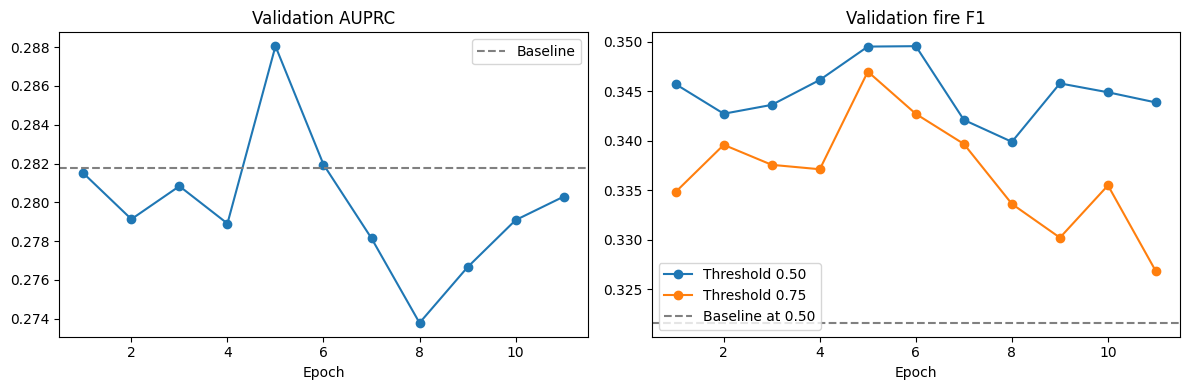

baseline | AUPRC: 0.2818 | F1@0.50: 0.3216 | IoU@0.50: 0 | FP@0.50: 219576
best_auprc_checkpoint | AUPRC: 0.2881 | F1@0.50: 0.3495 | IoU@0.50: 0.2118 | FP@0.50: 147648
best_f1_050_checkpoint | AUPRC: 0.282 | F1@0.50: 0.3495 | IoU@0.50: 0.2118 | FP@0.50: 129608
Saved: ../results/resnet_unet/run_003_loss_weight_10/validation_comparison.json


In [45]:
def evaluate_saved_checkpoint(path):
    checkpoint = torch.load(path, map_location=device, weights_only=True)
    weights = checkpoint.get("model_state_dict", checkpoint)
    model.load_state_dict(weights)
    result = validate()

    for threshold in ("at_050", "at_075"):
        counts = result[threshold]
        denominator = counts["tp"] + counts["fp"] + counts["fn"]
        counts["fire_iou"] = counts["tp"] / denominator if denominator else 0

    return result

comparison = {
    "baseline": starting_result,
    "best_auprc_epoch": best_auprc_epoch,
    "best_auprc_checkpoint": evaluate_saved_checkpoint(
        run_dir / "best_auprc.pt"
    ),
    "best_f1_050_epoch": best_f1_epoch,
    "best_f1_050_checkpoint": evaluate_saved_checkpoint(
        run_dir / "best_f1_050.pt"
    ),
}

with (run_dir / "validation_comparison.json").open("w") as file:
    json.dump(comparison, file, indent=2)

epochs = [row["epoch"] for row in history_e]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(
    epochs, [row["val_auprc"] for row in history_e], marker="o"
)
axes[0].axhline(
    starting_result["val_auprc"], color="gray", linestyle="--",
    label="Baseline"
)
axes[0].set_title("Validation AUPRC")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(
    epochs, [row["val_f1_050"] for row in history_e],
    marker="o", label="Threshold 0.50"
)
axes[1].plot(
    epochs, [row["val_f1_075"] for row in history_e],
    marker="o", label="Threshold 0.75"
)
axes[1].axhline(
    starting_result["at_050"]["f1"],
    color="gray", linestyle="--", label="Baseline at 0.50"
)
axes[1].set_title("Validation fire F1")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig(run_dir / "training_curves.png", dpi=180)
plt.show()

for name in ("baseline", "best_auprc_checkpoint", "best_f1_050_checkpoint"):
    result = comparison[name]
    print(
        name,
        "| AUPRC:", round(result["val_auprc"], 4),
        "| F1@0.50:", round(result["at_050"]["f1"], 4),
        "| IoU@0.50:", round(result["at_050"].get("fire_iou", 0), 4),
        "| FP@0.50:", result["at_050"]["fp"]
    )

print("Saved:", run_dir / "validation_comparison.json")

# verify the checkpoint and choose its threshold

## load epoch 5 and collect validation predictions

In [46]:
from pathlib import Path
import csv
import json

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

run_dir = Path("../results/resnet_unet/run_003_loss_weight_10")
checkpoint_path = run_dir / "best_auprc.pt"

with (run_dir / "training_history.csv").open() as file:
    history = list(csv.DictReader(file))

best_history_row = max(
    history, key=lambda row: float(row["val_auprc"])
)
print("Best AUPRC epoch:", best_history_row["epoch"])
print("Recorded AUPRC:", best_history_row["val_auprc"])

checkpoint = torch.load(
    checkpoint_path, map_location=device, weights_only=True
)
weights = checkpoint.get("model_state_dict", checkpoint)
model.load_state_dict(weights)
model.to(device)
model.eval()

validation_batches = DataLoader(
    val_loader.dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
)

label_parts = []
score_parts = []

with torch.no_grad():
    for inputs, targets, valid_mask in validation_batches:
        logits = model(inputs.to(device))
        probabilities = torch.sigmoid(logits).cpu()

        known = valid_mask.bool()
        label_parts.append(
            (targets[known] > 0.5).numpy().astype(np.uint8)
        )
        score_parts.append(
            probabilities[known].numpy().astype(np.float32)
        )

labels = np.concatenate(label_parts)
scores = np.concatenate(score_parts)

auprc = average_precision_numpy(labels, scores)

# Confirm this file corresponds to the epoch recorded in the CSV.
assert abs(
    auprc - float(best_history_row["val_auprc"])
) < 1e-4, "Checkpoint and training history do not match."

print("Valid pixels:", len(labels))
print("Fire pixels:", int(labels.sum()))
print("Verified checkpoint AUPRC:", round(auprc, 6))

Best AUPRC epoch: 5
Recorded AUPRC: 0.2880530354906692
Valid pixels: 7500385
Fire pixels: 102594
Verified checkpoint AUPRC: 0.288053


## compare thresholds for this checkpoint

In [47]:
def metrics_with_iou(threshold):
    result = threshold_metrics(labels, scores, threshold)
    denominator = result["tp"] + result["fp"] + result["fn"]
    result["fire_iou"] = (
        result["tp"] / denominator if denominator else 0.0
    )
    return {"threshold": float(threshold), **result}


rows = [
    metrics_with_iou(threshold)
    for threshold in np.arange(5, 96, 5) / 100
]

at_050 = next(
    row for row in rows if np.isclose(row["threshold"], 0.50)
)
at_075 = next(
    row for row in rows if np.isclose(row["threshold"], 0.75)
)
best_threshold_row = max(rows, key=lambda row: row["f1"])

assert abs(
    at_050["f1"] - float(best_history_row["val_f1_050"])
) < 1e-4, "Checkpoint F1 and training history do not match."

with (run_dir / "selected_checkpoint_thresholds.csv").open(
    "w", newline=""
) as file:
    writer = csv.DictWriter(file, fieldnames=rows[0].keys())
    writer.writeheader()
    writer.writerows(rows)

print("Epoch 5 at 0.50:", at_050)
print("Epoch 5 at 0.75:", at_075)
print("Highest validation F1:", best_threshold_row)

if best_threshold_row["threshold"] in (0.05, 0.95):
    print("Best threshold is at the search edge; extend the range.")

Epoch 5 at 0.50: {'threshold': 0.5, 'tp': 52990, 'fp': 147648, 'fn': 49604, 'tn': 7250143, 'precision': 0.2641074970843011, 'recall': 0.5165019396845819, 'f1': 0.3495013718868721, 'fire_iou': 0.21175502113953693}
Epoch 5 at 0.75: {'threshold': 0.75, 'tp': 38633, 'fp': 81458, 'fn': 63961, 'tn': 7316333, 'precision': 0.3216977125679693, 'recall': 0.3765619821821939, 'f1': 0.34697442575835824, 'fire_iou': 0.20990263621150546}
Highest validation F1: {'threshold': 0.65, 'tp': 45354, 'fp': 110393, 'fn': 57240, 'tn': 7287398, 'precision': 0.2912030408290368, 'recall': 0.4420726358266565, 'f1': 0.3511173216794856, 'fire_iou': 0.21294257395991303}


## save the comparison

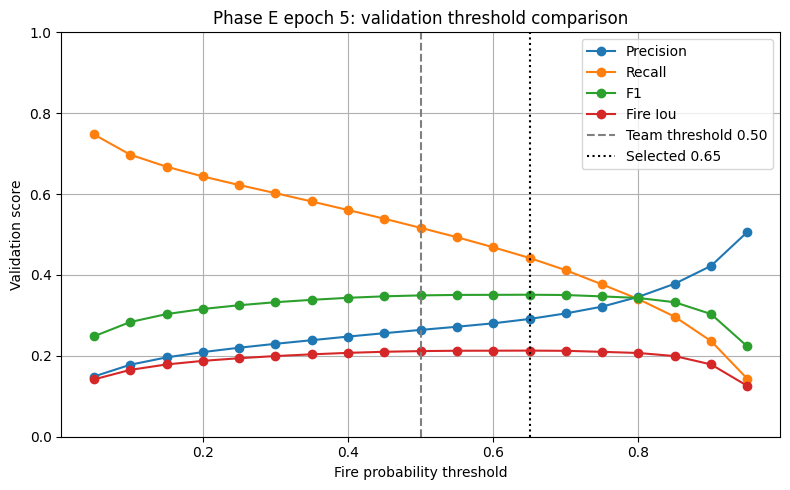

Saved Phase F results in: ../results/resnet_unet/run_003_loss_weight_10


In [48]:
with (run_dir / "starting_validation_metrics.json").open() as file:
    baseline = json.load(file)

comparison = {
    "checkpoint": str(checkpoint_path),
    "selected_epoch": int(best_history_row["epoch"]),
    "checkpoint_selection_metric": "validation AUPRC",
    "baseline_auprc": baseline["val_auprc"],
    "selected_checkpoint_auprc": auprc,
    "baseline_at_050": baseline["at_050"],
    "selected_checkpoint_at_050": at_050,
    "selected_checkpoint_at_075": at_075,
    "validation_f1_selected_threshold": best_threshold_row,
    "test_set_evaluated": False,
}

with (run_dir / "phase_f_selection.json").open("w") as file:
    json.dump(comparison, file, indent=2)

fig, ax = plt.subplots(figsize=(8, 5))
for metric in ("precision", "recall", "f1", "fire_iou"):
    ax.plot(
        [row["threshold"] for row in rows],
        [row[metric] for row in rows],
        marker="o",
        label=metric.replace("_", " ").title(),
    )

ax.axvline(0.50, color="gray", linestyle="--", label="Team threshold 0.50")
ax.axvline(
    best_threshold_row["threshold"],
    color="black",
    linestyle=":",
    label=f"Selected {best_threshold_row['threshold']:.2f}",
)
ax.set(
    xlabel="Fire probability threshold",
    ylabel="Validation score",
    title="Phase E epoch 5: validation threshold comparison",
    ylim=(0, 1),
)
ax.grid(True)
ax.legend()
fig.tight_layout()
fig.savefig(run_dir / "selected_checkpoint_thresholds.png", dpi=180)
plt.show()

print("Saved Phase F results in:", run_dir)

# Test evaluation

In [49]:
from pathlib import Path
import csv
import json

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

baseline_dir = Path("../results/resnet_unet/run_001_baseline")
run_dir = Path("../results/resnet_unet/run_003_loss_weight_10")

with (run_dir / "phase_f_selection.json").open() as file:
    selection = json.load(file)

selected_threshold = float(
    selection["validation_f1_selected_threshold"]["threshold"]
)
selected_checkpoint = run_dir / "best_auprc.pt"

assert selection["checkpoint_selection_metric"] == "validation AUPRC"
assert 0 < selected_threshold < 1
assert selected_checkpoint.exists()
assert (baseline_dir / "best.pt").exists()

if selected_threshold in (0.05, 0.95):
    raise ValueError(
        "The selected threshold is at the Phase F search boundary. "
        "Extend the validation search before evaluating the test set."
    )

print("Selected checkpoint:", selected_checkpoint)
print("Selected epoch:", selection["selected_epoch"])
print("Validation-selected threshold:", selected_threshold)
print("Shared comparison threshold: 0.50")

Selected checkpoint: ../results/resnet_unet/run_003_loss_weight_10/best_auprc.pt
Selected epoch: 5
Validation-selected threshold: 0.65
Shared comparison threshold: 0.50


## evaluate both checkpoints on the same test split

In [50]:
test_batches = DataLoader(
    test_loader.dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
)


def evaluate_test_checkpoint(checkpoint_path, thresholds):
    saved = torch.load(
        checkpoint_path,
        map_location=device,
        weights_only=True,
    )
    weights = saved.get("model_state_dict", saved)
    model.load_state_dict(weights)
    model.to(device)
    model.eval()

    label_parts = []
    score_parts = []
    image_count = 0

    with torch.no_grad():
        for inputs, targets, valid_mask in test_batches:
            probabilities = torch.sigmoid(
                model(inputs.to(device))
            ).cpu()

            known = valid_mask.bool()
            label_parts.append(
                (targets[known] > 0.5).numpy().astype(np.uint8)
            )
            score_parts.append(
                probabilities[known].numpy().astype(np.float32)
            )
            image_count += len(inputs)

    labels = np.concatenate(label_parts)
    scores = np.concatenate(score_parts)

    if len(labels) == 0 or int(labels.sum()) == 0:
        raise ValueError("No valid fire pixels found in the test split.")

    result = {
        "test_images": image_count,
        "valid_pixels": int(len(labels)),
        "fire_pixels": int(labels.sum()),
        "test_auprc": average_precision_numpy(labels, scores),
        "threshold_metrics": {},
    }

    for name, threshold in thresholds.items():
        metrics = threshold_metrics(labels, scores, threshold)
        denominator = (
            metrics["tp"] + metrics["fp"] + metrics["fn"]
        )
        metrics["fire_iou"] = (
            metrics["tp"] / denominator if denominator else 0.0
        )
        result["threshold_metrics"][name] = {
            "threshold": float(threshold),
            **metrics,
        }

    return result


# Choices are already fixed; test results do not select a new checkpoint.
baseline_test = evaluate_test_checkpoint(
    baseline_dir / "best.pt",
    {"team_050": 0.50},
)
selected_test = evaluate_test_checkpoint(
    selected_checkpoint,
    {
        "team_050": 0.50,
        "validation_selected": selected_threshold,
    },
)

assert baseline_test["valid_pixels"] == selected_test["valid_pixels"]
assert baseline_test["fire_pixels"] == selected_test["fire_pixels"]

print("Baseline test AUPRC:", round(baseline_test["test_auprc"], 4))
print("Selected model test AUPRC:", round(selected_test["test_auprc"], 4))
print("\nBaseline at 0.50:")
print(baseline_test["threshold_metrics"]["team_050"])
print("\nSelected model at 0.50:")
print(selected_test["threshold_metrics"]["team_050"])
print("\nSelected model at validation-selected threshold:")
print(selected_test["threshold_metrics"]["validation_selected"])

Baseline test AUPRC: 0.3368
Selected model test AUPRC: 0.3368

Baseline at 0.50:
{'threshold': 0.5, 'tp': 60328, 'fp': 223265, 'fn': 24003, 'tn': 6420103, 'precision': 0.21272739454076794, 'recall': 0.7153715715454578, 'f1': 0.32793729139713634, 'fire_iou': 0.19612738787240405}

Selected model at 0.50:
{'threshold': 0.5, 'tp': 52578, 'fp': 141408, 'fn': 31753, 'tn': 6501960, 'precision': 0.2710401781571866, 'recall': 0.6234717956623306, 'f1': 0.3778281599758549, 'fire_iou': 0.23291500361036419}

Selected model at validation-selected threshold:
{'threshold': 0.65, 'tp': 47376, 'fp': 105952, 'fn': 36955, 'tn': 6537416, 'precision': 0.3089846603360117, 'recall': 0.561786294482456, 'f1': 0.39868887776183526, 'fire_iou': 0.2489765244399132}


## save report

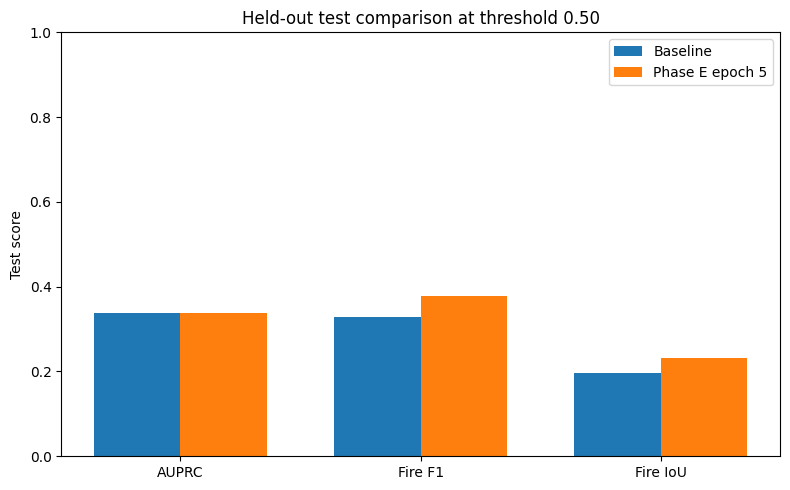

Saved: ../results/resnet_unet/run_003_loss_weight_10/phase_g_final_test.json
Saved: ../results/resnet_unet/run_003_loss_weight_10/phase_g_test_comparison.csv


In [51]:
report = {
    "split": "held-out test",
    "checkpoint_selected_using": "validation AUPRC",
    "selected_epoch": selection["selected_epoch"],
    "threshold_selected_using": "validation fire F1",
    "validation_selected_threshold": selected_threshold,
    "baseline_checkpoint": str(baseline_dir / "best.pt"),
    "selected_checkpoint": str(selected_checkpoint),
    "baseline_test": baseline_test,
    "selected_model_test": selected_test,
}

json_path = run_dir / "phase_g_final_test.json"
with json_path.open("w") as file:
    json.dump(report, file, indent=2)

comparison_rows = []
for name, result, threshold_name in (
    ("Baseline", baseline_test, "team_050"),
    ("Phase E epoch 5", selected_test, "team_050"),
    ("Phase E epoch 5", selected_test, "validation_selected"),
):
    metrics = result["threshold_metrics"][threshold_name]
    comparison_rows.append({
        "model": name,
        "threshold_source": threshold_name,
        "threshold": metrics["threshold"],
        "test_auprc": result["test_auprc"],
        **{
            key: value for key, value in metrics.items()
            if key != "threshold"
        },
    })

csv_path = run_dir / "phase_g_test_comparison.csv"
with csv_path.open("w", newline="") as file:
    writer = csv.DictWriter(
        file, fieldnames=comparison_rows[0].keys()
    )
    writer.writeheader()
    writer.writerows(comparison_rows)

# Plot only the shared 0.50 comparison.
metric_names = ["test_auprc", "f1", "fire_iou"]
baseline_values = [
    baseline_test["test_auprc"],
    baseline_test["threshold_metrics"]["team_050"]["f1"],
    baseline_test["threshold_metrics"]["team_050"]["fire_iou"],
]
selected_values = [
    selected_test["test_auprc"],
    selected_test["threshold_metrics"]["team_050"]["f1"],
    selected_test["threshold_metrics"]["team_050"]["fire_iou"],
]

x = np.arange(len(metric_names))
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - 0.18, baseline_values, 0.36, label="Baseline")
ax.bar(x + 0.18, selected_values, 0.36, label="Phase E epoch 5")
ax.set_xticks(x, ["AUPRC", "Fire F1", "Fire IoU"])
ax.set_ylabel("Test score")
ax.set_title("Held-out test comparison at threshold 0.50")
ax.set_ylim(0, 1)
ax.legend()
fig.tight_layout()
fig.savefig(run_dir / "phase_g_test_comparison.png", dpi=180)
plt.show()

print("Saved:", json_path)
print("Saved:", csv_path)

In [52]:
from pathlib import Path
import csv
import json

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, Subset

run_dir = Path("../results/resnet_unet/run_003_loss_weight_10")

with (run_dir / "phase_g_final_test.json").open() as file:
    final_report = json.load(file)

selected_threshold = float(
    final_report["validation_selected_threshold"]
)
checkpoint_path = Path(final_report["selected_checkpoint"])

dataset = test_loader.dataset
fire_indices = []
no_fire_indices = []

# Select by target labels only; predictions play no part.
for index in range(len(dataset)):
    _, target, valid_mask = dataset[index]
    known = valid_mask.bool()
    if not known.any():
        continue

    has_fire = bool(((target > 0.5) & known).any())
    (fire_indices if has_fire else no_fire_indices).append(index)

rng = np.random.default_rng(42)
chosen_fire = [
    int(i) for i in rng.choice(
        fire_indices, size=min(3, len(fire_indices)), replace=False
    )
]
chosen_no_fire = [
    int(i) for i in rng.choice(
        no_fire_indices, size=min(3, len(no_fire_indices)), replace=False
    )
]
chosen_indices = chosen_fire + chosen_no_fire

if not chosen_indices:
    raise ValueError("No test patches have valid target pixels.")

print("Test patches with fire:", len(fire_indices))
print("Test patches without fire:", len(no_fire_indices))
print("Gallery indices:", chosen_indices)

Test patches with fire: 1487
Test patches without fire: 200
Gallery indices: [1102, 150, 1300, 151, 1146, 1407]


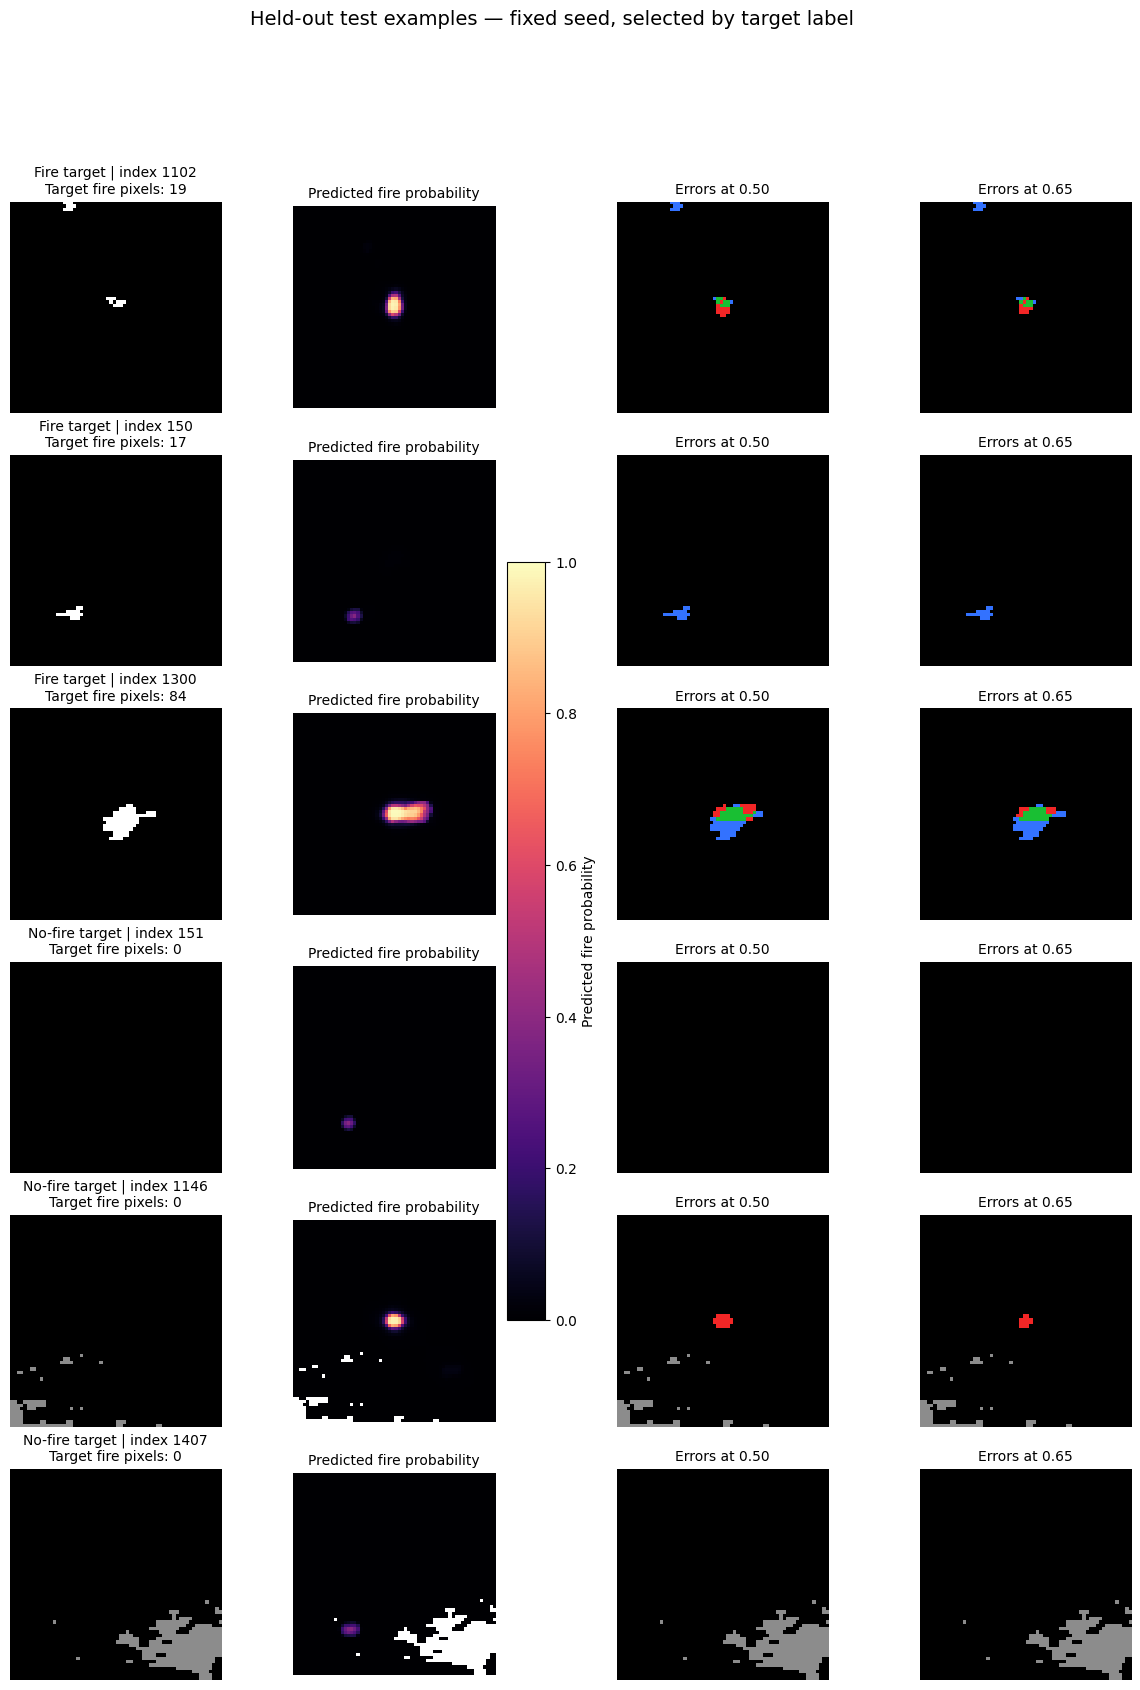

Saved: ../results/resnet_unet/run_003_loss_weight_10/phase_h_test_gallery.png
Saved: ../results/resnet_unet/run_003_loss_weight_10/phase_h_gallery_cases.csv


In [53]:
saved = torch.load(
    checkpoint_path, map_location=device, weights_only=True
)
weights = saved.get("model_state_dict", saved)
model.load_state_dict(weights)
model.to(device)
model.eval()


def error_picture(probability, target, valid, threshold):
    fire = target > 0.5
    predicted = probability >= threshold

    picture = np.zeros((*target.shape, 3), dtype=np.float32)
    picture[~valid] = (0.55, 0.55, 0.55)          # unknown
    picture[valid & fire & predicted] = (0.10, 0.75, 0.20)
    picture[valid & ~fire & predicted] = (0.95, 0.15, 0.15)
    picture[valid & fire & ~predicted] = (0.20, 0.45, 1.00)
    return picture


def patch_counts(probability, target, valid, threshold):
    fire = target > 0.5
    predicted = probability >= threshold
    return {
        "tp": int(np.sum(valid & fire & predicted)),
        "fp": int(np.sum(valid & ~fire & predicted)),
        "fn": int(np.sum(valid & fire & ~predicted)),
    }


gallery_loader = DataLoader(
    Subset(dataset, chosen_indices),
    batch_size=8,
    shuffle=False,
    num_workers=0,
)

gallery_rows = []
position = 0

with torch.no_grad():
    for inputs, targets, valid_masks in gallery_loader:
        probabilities = torch.sigmoid(
            model(inputs.to(device))
        ).cpu().numpy()

        for item in range(len(inputs)):
            index = chosen_indices[position]
            target = targets[item, 0].numpy()
            valid = valid_masks[item, 0].bool().numpy()
            probability = probabilities[item, 0]

            gallery_rows.append({
                "index": index,
                "category": (
                    "Fire target" if index in chosen_fire
                    else "No-fire target"
                ),
                "target": target,
                "valid": valid,
                "probability": probability,
                "fire_pixels": int(np.sum(valid & (target > 0.5))),
            })
            position += 1

fig, axes = plt.subplots(
    len(gallery_rows), 4,
    figsize=(15, 3.2 * len(gallery_rows)),
    squeeze=False,
)

case_records = []

for row_number, case in enumerate(gallery_rows):
    target = case["target"]
    valid = case["valid"]
    probability = case["probability"]

    truth = np.zeros((*target.shape, 3), dtype=np.float32)
    truth[~valid] = (0.55, 0.55, 0.55)
    truth[valid & (target > 0.5)] = (1, 1, 1)

    axes[row_number, 0].imshow(truth, interpolation="nearest")
    heatmap = axes[row_number, 1].imshow(
        np.ma.masked_where(~valid, probability),
        cmap="magma", vmin=0, vmax=1,
        interpolation="nearest",
    )
    axes[row_number, 1].set_facecolor("0.55")

    axes[row_number, 2].imshow(
        error_picture(probability, target, valid, 0.50),
        interpolation="nearest",
    )
    axes[row_number, 3].imshow(
        error_picture(
            probability, target, valid, selected_threshold
        ),
        interpolation="nearest",
    )

    titles = (
        f"{case['category']} | index {case['index']}\n"
        f"Target fire pixels: {case['fire_pixels']}",
        "Predicted fire probability",
        "Errors at 0.50",
        f"Errors at {selected_threshold:.2f}",
    )
    for axis, title in zip(axes[row_number], titles):
        axis.set_title(title, fontsize=10)
        axis.axis("off")

    at_050 = patch_counts(probability, target, valid, 0.50)
    at_selected = patch_counts(
        probability, target, valid, selected_threshold
    )
    case_records.append({
        "test_index": case["index"],
        "category": case["category"],
        "valid_pixels": int(valid.sum()),
        "fire_pixels": case["fire_pixels"],
        **{f"{key}_050": value for key, value in at_050.items()},
        **{
            f"{key}_selected": value
            for key, value in at_selected.items()
        },
    })

fig.colorbar(
    heatmap, ax=axes[:, 1].tolist(),
    label="Predicted fire probability",
    shrink=0.7,
)
fig.suptitle(
    "Held-out test examples — fixed seed, selected by target label",
    fontsize=14,
)
figure_path = run_dir / "phase_h_test_gallery.png"
fig.savefig(figure_path, dpi=180, bbox_inches="tight")
plt.show()

cases_path = run_dir / "phase_h_gallery_cases.csv"
with cases_path.open("w", newline="") as file:
    writer = csv.DictWriter(
        file, fieldnames=case_records[0].keys()
    )
    writer.writeheader()
    writer.writerows(case_records)

print("Saved:", figure_path)
print("Saved:", cases_path)


In [54]:
baseline = final_report["baseline_test"]
selected = final_report["selected_model_test"]

baseline_050 = baseline["threshold_metrics"]["team_050"]
selected_050 = selected["threshold_metrics"]["team_050"]
selected_custom = selected["threshold_metrics"]["validation_selected"]

def table_row(name, auprc, metrics):
    return (
        f"| {name} | {metrics['threshold']:.2f} | "
        f"{auprc:.4f} | {metrics['precision']:.4f} | "
        f"{metrics['recall']:.4f} | {metrics['f1']:.4f} | "
        f"{metrics['fire_iou']:.4f} | "
        f"{metrics['fp']} | {metrics['fn']} |"
    )

lines = [
    "# ResNet–UNet final test results",
    "",
    "The model checkpoint was selected by validation AUPRC. "
    "The optional threshold was selected by validation fire-pixel F1. "
    "Neither choice used test results.",
    "",
    "| Model | Threshold | AUPRC | Precision | Recall | "
    "Fire F1 | Fire IoU | FP | FN |",
    "|---|---:|---:|---:|---:|---:|---:|---:|---:|",
    table_row("Baseline", baseline["test_auprc"], baseline_050),
    table_row("Phase E", selected["test_auprc"], selected_050),
    table_row(
        "Phase E, validation threshold",
        selected["test_auprc"],
        selected_custom,
    ),
    "",
    "The first two rows use the team's shared threshold of 0.50. "
    "The third row shows the separately selected threshold. "
    "AUPRC is the same in the two Phase E rows because the "
    "checkpoint and its probability scores are the same.",
    "",
    "The accompanying gallery uses a fixed random seed and "
    "selects patches by whether the target contains fire, "
    "without ranking patches by model performance.",
]

summary_path = run_dir / "phase_h_results_summary.md"
summary_path.write_text("\n".join(lines) + "\n")

print(summary_path.read_text())
print("Saved:", summary_path)

# ResNet–UNet final test results

The model checkpoint was selected by validation AUPRC. The optional threshold was selected by validation fire-pixel F1. Neither choice used test results.

| Model | Threshold | AUPRC | Precision | Recall | Fire F1 | Fire IoU | FP | FN |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| Baseline | 0.50 | 0.3368 | 0.2127 | 0.7154 | 0.3279 | 0.1961 | 223265 | 24003 |
| Phase E | 0.50 | 0.3368 | 0.2710 | 0.6235 | 0.3778 | 0.2329 | 141408 | 31753 |
| Phase E, validation threshold | 0.65 | 0.3368 | 0.3090 | 0.5618 | 0.3987 | 0.2490 | 105952 | 36955 |

The first two rows use the team's shared threshold of 0.50. The third row shows the separately selected threshold. AUPRC is the same in the two Phase E rows because the checkpoint and its probability scores are the same.

The accompanying gallery uses a fixed random seed and selects patches by whether the target contains fire, without ranking patches by model performance.

Saved: ../results/resnet_unet/run_003_lo